# 🏥 PBL #2 최종 소스코드 — 서울시 청년 비만 진단 및 정책 타겟팅
**하이파이브 팀 | 데이터사이언스개론 26-1**

공공데이터(지역사회건강조사·서울시 체육시설·상권분석)를 활용해 **서울 청년 비만**이라는 사회문제를
진단하고, 데이터 기반 정책 대안을 도출한다. 노트북을 **위에서부터 순서대로 실행**하면
`원시자료 → 전처리 → 통합 마스터 → 6대 분석기법 → 시각화 → 정책 인사이트`가 한 번에 수행된다.

| 단계 | 내용 | 가이드라인 분석전략 매핑 |
|---|---|---|
| PART A~D | 전처리·정제·통합 (원시자료 → 마스터) | 데이터 전처리 |
| PART E | 탐색적 분석·상관 (문제 정의) | 문제 정의 |
| PART F | 군집분석 (자치구 정책 타겟 그룹) | 군집 분석 (비/계층적) |
| PART G | 선형회귀 (BMI 결정요인) | 예측 모델링 |
| PART H | 로지스틱 회귀 (비만 위험요인) | 분류 모델링 |
| PART I | 의사결정트리·랜덤포레스트·뉴럴넷 | 예측·분류 모델링 |
| PART J | 연관분석 (위험요인 동시발생) | 연관 분석 |
| PART K | 자치구 회귀 (H1/H2 검정) | 예측 모델링 |
| PART L | 종합 정책 인사이트 | 데이터 기반 의사결정 |

**가설** — H1: 배달친화 외식환경↑ → 청년 비만율↑ · H2: 체육시설↑ → 청년 비만율↓

**데이터 출처**: 질병관리청 지역사회건강조사(2019~2025), 서울 열린데이터광장(공공·등록체육시설 통계,
상권분석서비스 점포·추정매출·영역 2021~2025).

---

# 🏙️ PBL #2 — 데이터 병합 및 전처리 (최종 통합본)
**서울시 청년 비만율 분석 | 하이파이브 팀 | 데이터사이언스개론 26-1**

---

## 📋 이 노트북 한 장으로 끝나는 전처리

원시자료(지역사회건강조사)부터 외부 공공데이터(체육시설·상권)까지 **모든 데이터를 로드·정제·통합**하여 분석용 마스터 테이블을 만듭니다.

| 구분 | 데이터 | 출처 | 범위 |
|------|--------|------|------|
| 원시 | 지역사회건강조사 | 질병관리청 | 2019~2025 (7개년) |
| 외부① | 공공체육시설 통계 | 서울 열린데이터광장 | 2011~2024 |
| 외부② | 등록·신고 체육시설 통계 | 서울 열린데이터광장 | 2010~2024 |
| 외부③ | 상권분석-점포 | 서울 열린데이터광장 | 2021~2025 |
| 외부④ | 상권분석-추정매출 | 서울 열린데이터광장 | 2021~2025 |
| 매핑 | 상권 영역(상권↔자치구) | 서울 열린데이터광장 | - |

## 🎯 변수 설계

- **종속변수**: 비만여부(개인 BMI≥25), 비만율(자치구 %)
- **독립변수(개인)**: 걷기·수면·아침식사·스트레스·흡연·음주·우울
- **독립변수(환경)**: 체육시설 수(H2), 배달친화 외식업 비중·청년 매출비중(H1)
- **통제변수**: 연령·성별·연도

## ⚙️ 전처리에서 해결한 핵심 이슈

1. 연도별 컬럼명 상이(원시자료 2019~21 소문자 / 2022~ 대문자) → 표준화
2. 결측 특수코드(99999·77·88·99 등) → NaN 변환 후 처리
3. 체육시설 결측(중구 2020) → 시계열 선형보간
4. 상권에 자치구 없음 → 영역(DBF)으로 1,650개 상권→25개 자치구 매핑
5. 2025년 상권만 영문 컬럼 → 한글 표준화
6. 비만 이상치 → 생물학적 범위(BMI 10~60)만 제거 (IQR 미사용)

---
# PART 0. 환경 설정
import · 한글폰트 · 경로 자동탐색 · 서울 25개구 · 통계표 공용 로더

**필요 라이브러리** (Colab 등에서 미설치 시 아래 셀의 주석을 해제해 1회 설치)

In [2]:
# 필요 시 1회 설치 (이미 설치돼 있으면 생략)
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels scipy

In [3]:
!pip install pandas numpy pyreadstat dbfread statsmodels matplotlib seaborn

In [4]:
# ============================================================
# PART 0. 환경 설정 (이 셀 하나로 전체 세팅)
#   · 라이브러리 import (분석 + 원시데이터 전처리용 pyreadstat·dbfread)
#   · 한글 폰트 견고 설정 (Windows·Mac·Linux·Colab)
#   · 데이터 경로 자동 탐색 · 서울 25개구 · 통계표 공용 로더
# ============================================================
import os, glob, re, csv, zipfile, unicodedata, warnings
import numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
warnings.filterwarnings('ignore')

# ── 분석 라이브러리 ──
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, classification_report,
                             accuracy_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 원시데이터(.sav/.dbf) 전처리용. 미설치 환경이면 자동 설치 후 import ──
try:
    import pyreadstat
    from dbfread import DBF
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyreadstat', 'dbfread'])
    import pyreadstat
    from dbfread import DBF

# ── 한글 폰트 견고 설정 (OS·환경 무관, 깨짐 방지) ──
def set_korean_font(verbose=True):
    """설치된 한글 폰트를 자동 탐지·등록. 폰트 캐시가 못 잡으면 '파일 경로'로 직접 등록."""
    import os, glob, platform
    name_cands = ['Malgun Gothic','AppleGothic','Apple SD Gothic Neo','AppleSDGothicNeo',
                  'NanumGothic','NanumBarunGothic','Noto Sans CJK KR','Noto Sans KR',
                  'Noto Sans CJK JP','Noto Sans CJK SC','Gulim','Dotum','Batang','UnDotum']
    installed = {f.name for f in fm.fontManager.ttflist}
    for nm in name_cands:
        if nm in installed:
            plt.rcParams['font.family'] = nm; plt.rcParams['axes.unicode_minus'] = False
            if verbose: print('한글 폰트 설정:', nm)
            return nm
    path_cands = ['C:/Windows/Fonts/malgun.ttf','C:/Windows/Fonts/malgunbd.ttf','C:/Windows/Fonts/gulim.ttc',
        '/System/Library/Fonts/Supplemental/AppleGothic.ttf','/Library/Fonts/AppleGothic.ttf',
        '/System/Library/Fonts/AppleSDGothicNeo.ttc',
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc']
    path_cands += glob.glob('/usr/share/fonts/**/*Nanum*.*', recursive=True)
    path_cands += glob.glob('/usr/share/fonts/**/NotoSansCJK*.*', recursive=True)
    for p in path_cands:
        if os.path.exists(p):
            try:
                fm.fontManager.addfont(p); nm = fm.FontProperties(fname=p).get_name()
                plt.rcParams['font.family'] = nm; plt.rcParams['axes.unicode_minus'] = False
                if verbose: print('한글 폰트 등록:', nm)
                return nm
            except Exception:
                pass
    if platform.system() == 'Linux':   # Colab 등: 나눔폰트 설치 후 재탐색
        os.system('apt-get -qq -y install fonts-nanum >/dev/null 2>&1')
        for p in glob.glob('/usr/share/fonts/**/*Nanum*.*', recursive=True):
            try:
                fm.fontManager.addfont(p); nm = fm.FontProperties(fname=p).get_name()
                plt.rcParams['font.family'] = nm; plt.rcParams['axes.unicode_minus'] = False
                if verbose: print('나눔폰트 설치·설정:', nm)
                return nm
            except Exception:
                pass
    print('⚠ 한글 폰트를 찾지 못했습니다. Colab은 "!apt-get install -y fonts-nanum" 실행 후 [런타임 다시 시작].')
    plt.rcParams['axes.unicode_minus'] = False
    return None

sns.set_style('whitegrid')          # ① seaborn 스타일 먼저 (set_style이 font.family를 리셋하므로)
pd.set_option('display.max_columns', 60)
set_korean_font()                   # ② 한글 폰트는 seaborn 뒤에 적용 → 폰트 유지(한글 안 깨짐)

# ── 데이터(CSV) 폴더 자동 탐색 ──
_CANDS = ['', './', './data/', '../data/', '/content/', '/content/data/']
BASE = next((c for c in _CANDS
             if os.path.exists(c+'seoul_youth_individual.csv') or os.path.exists(c+'master_full.csv')), './')
BASE = BASE or './'        # 빈 문자열 → 현재폴더로 정규화 (os.makedirs 등 안전)
OUT  = BASE
WORK = './_work/'; os.makedirs(WORK, exist_ok=True)

# ── 서울 25개 자치구 ──
GU25 = ['종로구','중구','용산구','성동구','광진구','동대문구','중랑구','성북구','강북구','도봉구',
        '노원구','은평구','서대문구','마포구','양천구','강서구','구로구','금천구','영등포구','동작구',
        '관악구','서초구','강남구','송파구','강동구']

# ── 원시 데이터 존재 여부(KCHS .sav / 상권 zip 등). 없으면 전처리 PART A~D는 건너뜀 ──
RAW_AVAILABLE = bool(glob.glob(BASE+'*chs*') or glob.glob(BASE+'*상권*.zip')
                     or glob.glob(BASE+'*추정매출*') or glob.glob(BASE+'*점포-상권*')
                     or glob.glob(BASE+'*영역*.zip'))

# ── 통계표(피벗 CSV) 안전 로드 / 숫자 변환 — 결측 시각화·전처리 공용 ──
def read_seoul_stat(path):
    df = pd.read_csv(path, encoding='utf-8-sig', engine='python', quoting=csv.QUOTE_NONE)
    df = df.dropna(axis=1, how='all')
    df.columns = [str(c).replace('"','').replace(' ','').replace('년','') for c in df.columns]
    for c in df.columns:
        df[c] = df[c].astype(str).str.replace('"','').str.strip()
    return df

def to_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace('-','',regex=False).str.replace(',','',regex=False).replace('',np.nan),
        errors='coerce')

print(f'✅ 환경 설정 완료 | BASE={os.path.abspath(BASE)}')
print(f'   원시데이터 존재 = {RAW_AVAILABLE} (False면 전처리 PART A~D 건너뛰고 완료 CSV 사용)')
print(f'   matplotlib 폰트 = {plt.rcParams["font.family"]}')

한글 폰트 설정: Malgun Gothic
✅ 환경 설정 완료 | BASE=c:\Users\AIS\Downloads\1학년_2학기\강서윤_\USB 드라이브\pythone\PBL#2 - 복사본 - 복사본
   원시데이터 존재 = True (False면 전처리 PART A~D 건너뛰고 완료 CSV 사용)
   matplotlib 폰트 = ['Malgun Gothic']


---
# 전처리 파이프라인 (PART A–D)
> **실행 안내** — 아래 PART A~D는 원시 데이터(KCHS `.sav`, 상권 `zip`, 상권 영역 shapefile)를 정제하는 코드입니다. 원시 데이터는 용량이 커 데이터 폴더에 별도 보관하며, **본 제출본은 전처리가 끝난 CSV로 분석을 재현**합니다. 원시 데이터가 없는 환경(`RAW_AVAILABLE=False`)에서는 이 섹션이 자동으로 **건너뛰어지고**, 다음 '데이터 로드' 단계에서 완료본 CSV를 사용합니다. (전처리 로직 문서화 목적)

## PART A. 원시자료 전처리 (지역사회건강조사 → 청년 비만율)

In [5]:
if RAW_AVAILABLE:
    # 연도 ↔ 파일 stem 매핑
    CHS = {2019:'chs19_all', 2020:'chs20_all_re', 2021:'chs21_all',
           2022:'chs22_all', 2023:'chs23_all', 2024:'chs24_all', 2025:'chs25_all'}

    def get_sas_path(stem):
        """sas7bdat가 이미 있으면 그 경로, 없으면 zip 풀어서 경로 반환"""
        # 1) 현재 폴더 또는 작업폴더에 이미 풀린 파일
        for cand in [BASE+stem+'.sas7bdat', WORK+stem+'.sas7bdat']:
            if os.path.exists(cand):
                return cand
        # 2) zip 해제
        zip_path = BASE+stem+'.zip'
        if not os.path.exists(zip_path):
            return None
        with zipfile.ZipFile(zip_path) as z:
            targets = [n for n in z.namelist() if n.endswith('.sas7bdat') and 'ctv' not in n.lower()]
            if not targets:
                return None
            z.extract(targets[0], WORK)
            return WORK+targets[0]

    SAS_PATHS = {}
    for y, stem in CHS.items():
        p = get_sas_path(stem)
        if p:
            SAS_PATHS[y] = p
            print(f'  ✅ {y}: {os.path.basename(p)}')
        else:
            print(f'  ⚠️ {y}: 파일 없음 → 건너뜀')
    print(f'\n총 {len(SAS_PATHS)}개 연도 준비')

  ✅ 2019: chs19_all.sas7bdat
  ✅ 2020: chs20_all_re.sas7bdat
  ✅ 2021: chs21_all.sas7bdat
  ✅ 2022: chs22_all.sas7bdat
  ✅ 2023: chs23_all.sas7bdat
  ✅ 2024: chs24_all.sas7bdat
  ✅ 2025: chs25_all.sas7bdat

총 7개 연도 준비


In [6]:
if RAW_AVAILABLE:
    VAR_MAP = {
        'age':       {y:'age'         for y in range(2019,2026)},
        'sex':       {y:'sex'         for y in range(2019,2026)},
        'sigungu':   {y:'signgu_code' for y in range(2019,2026)},
        # 시도코드: 2019~2021 소문자, 2022~ 대문자
        'sido':      {2019:'ctprvn_code',2020:'ctprvn_code',2021:'ctprvn_code',
                      2022:'CTPRVN_CODE',2023:'CTPRVN_CODE',2024:'CTPRVN_CODE',2025:'CTPRVN_CODE'},
        # 키·몸무게: 2019 측정값 / 2020 BMI직접 / 2021~ 자가보고
        'height':    {2019:'mea_14z1',2021:'oba_02z1',2022:'oba_02z1',2023:'oba_02z1',
                      2024:'oba_02z1',2025:'oba_02z1'},
        'weight':    {2019:'mea_10z1',2021:'oba_03z1',2022:'oba_03z1',2023:'oba_03z1',
                      2024:'oba_03z1',2025:'oba_03z1'},
        'bmi_given': {2020:'oba_bmi'},
        # 공통 행태변수
        'walk_days': {y:'phb_01z1' for y in range(2019,2026)},
        'breakfast': {y:'nua_01z2' for y in range(2019,2026)},
        'stress':    {y:'mta_01z1' for y in range(2019,2026)},
        'depress':   {y:'mtb_01z1' for y in range(2019,2026)},
        'smoke':     {y:'sma_03z2' for y in range(2019,2026)},
        'drink_freq':{y:'drb_01z3' for y in range(2020,2026)},  # 2019 변수명 상이→제외
        # 수면: 2019 mtc_01z1 / 2023 없음 / 그외 mtc_17z1
        'sleep':     {2019:'mtc_01z1',2020:'mtc_17z1',2021:'mtc_17z1',2022:'mtc_17z1',
                      2024:'mtc_17z1',2025:'mtc_17z1'},
    }

    # 연도별 실제 컬럼 캐시
    YEAR_COLS = {}
    for y,p in SAS_PATHS.items():
        _, meta = pyreadstat.read_sas7bdat(p, row_limit=1)
        YEAR_COLS[y] = set(meta.column_names)
    print('✅ 변수 매핑 정의 + 연도별 컬럼 캐시 완료')

✅ 변수 매핑 정의 + 연도별 컬럼 캐시 완료


In [7]:
if RAW_AVAILABLE:
    def load_year(year):
        needed = {}
        for std, ymap in VAR_MAP.items():
            col = ymap.get(year)
            if col and col in YEAR_COLS[year]:
                needed[col] = std
        df, _ = pyreadstat.read_sas7bdat(SAS_PATHS[year], usecols=list(needed.keys()))
        df = df.rename(columns=needed)
        df['year'] = year
        # 서울 필터 (시도코드 11)
        df['sido'] = df['sido'].astype(str).str.strip().str.replace('.0','',regex=False)
        df = df[df['sido']=='11'].copy()
        return df

    frames = [load_year(y) for y in sorted(SAS_PATHS)]
    df_raw = pd.concat(frames, ignore_index=True)
    print(f'[서울 필터] 병합 {df_raw.shape[0]:,}행')

    # 청년 필터 (19~39세)
    df = df_raw[(df_raw['age']>=19) & (df_raw['age']<=39)].copy()
    print(f'[청년 필터] {df_raw.shape[0]:,} → {df.shape[0]:,}행')
    print(df['year'].value_counts().sort_index().to_string())

[서울 필터] 병합 160,434행
[청년 필터] 160,434 → 46,293행
year
2019    6805
2020    7110
2021    6933
2022    6582
2023    6453
2024    6304
2025    6106


In [8]:
if RAW_AVAILABLE:
    # 결측 특수코드 → NaN
    for c in ['height','weight','bmi_given']:
        if c in df.columns:
            df[c] = df[c].replace([9999,99999,8888,88888,7777,77777], np.nan)
            df.loc[df[c]>=900, c] = np.nan
    for c in ['walk_days','sleep','breakfast','drink_freq']:
        if c in df.columns:
            df[c] = df[c].replace([77,88,99], np.nan)
    for c in ['smoke','stress','depress']:
        if c in df.columns:
            df[c] = df[c].replace([7,8,9], np.nan)

    # BMI 계산 (키·몸무게 있으면 계산, 2020년은 제공된 BMI 사용)
    df['BMI'] = np.nan
    m = df['height'].notna() & df['weight'].notna()
    df.loc[m,'BMI'] = df.loc[m,'weight'] / (df.loc[m,'height']/100)**2
    if 'bmi_given' in df.columns:
        df['BMI'] = df['BMI'].fillna(df['bmi_given'])
    df['BMI'] = df['BMI'].round(2)

    # 이상치 제거 (생물학적 불가능 범위)
    before = len(df)
    df = df[(df['BMI']>=10) & (df['BMI']<=60)].copy()
    print(f'[이상치 제거] BMI 비현실값: {before:,} → {len(df):,}행')

    # 비만여부
    df['비만여부'] = (df['BMI']>=25).astype(int)
    print(f'청년 비만율: {df["비만여부"].mean()*100:.1f}%, BMI 평균: {df["BMI"].mean():.2f}')

[이상치 제거] BMI 비현실값: 46,293 → 45,621행
청년 비만율: 27.3%, BMI 평균: 23.19


In [9]:
if RAW_AVAILABLE:
    # 행정기관코드 → 자치구명
    GU_CODE = {
        '11110':'종로구','11140':'중구','11170':'용산구','11200':'성동구','11215':'광진구',
        '11230':'동대문구','11260':'중랑구','11290':'성북구','11305':'강북구','11320':'도봉구',
        '11350':'노원구','11380':'은평구','11410':'서대문구','11440':'마포구','11470':'양천구',
        '11500':'강서구','11530':'구로구','11545':'금천구','11560':'영등포구','11590':'동작구',
        '11620':'관악구','11650':'서초구','11680':'강남구','11710':'송파구','11740':'강동구'}
    df['sigungu'] = df['sigungu'].astype(str).str.strip().str.replace('.0','',regex=False)
    df['자치구'] = df['sigungu'].map(GU_CODE)
    print(f'자치구 매핑: {df["자치구"].nunique()}개, 매핑실패 {df["자치구"].isna().sum()}행')

    # 잔여 결측: 빈도형 중앙값, 범주형 최빈값
    for v in ['walk_days','sleep','breakfast','drink_freq']:
        if v in df.columns and df[v].notna().any():
            df[v] = df[v].fillna(df[v].median())
    for v in ['smoke','stress','depress']:
        if v in df.columns and df[v].notna().any():
            df[v] = df[v].fillna(df[v].mode()[0])

    # 개인 수준 저장
    keep = ['year','자치구','age','sex','BMI','비만여부','walk_days','sleep',
            'breakfast','stress','smoke','drink_freq','depress']
    keep = [c for c in keep if c in df.columns]
    df_indiv = df[keep].copy()
    df_indiv.to_csv(OUT+'seoul_youth_individual.csv', index=False, encoding='utf-8-sig')

    # 자치구×연도 집계
    obesity_yr = df_indiv.groupby(['자치구','year']).agg(
        표본수=('비만여부','size'), 비만율=('비만여부','mean'),
        평균BMI=('BMI','mean'), 평균걷기일수=('walk_days','mean'),
        평균수면=('sleep','mean'), 평균아침식사=('breakfast','mean'),
        흡연율=('smoke', lambda x:(x==1).mean())).reset_index()
    obesity_yr['비만율'] = (obesity_yr['비만율']*100).round(2)
    obesity_yr.to_csv(OUT+'seoul_youth_district_year.csv', index=False, encoding='utf-8-sig')

    print(f'\n✅ PART A 완료: 개인 {len(df_indiv):,}행, 자치구×연도 {len(obesity_yr)}행')
    print(f'   결측: 개인 {df_indiv.isna().sum().sum()}개')

자치구 매핑: 25개, 매핑실패 0행

✅ PART A 완료: 개인 45,621행, 자치구×연도 175행
   결측: 개인 0개


---
# PART B. 체육시설 통계 전처리 (가설 H2)

## B-1. 통계표 안전 로드 함수

## B-2. 공공체육시설 (2011~2024) → long 변환

In [10]:
if RAW_AVAILABLE:
    pub = read_seoul_stat(BASE+'서울시_공공체육시설_통계.csv')
    pub = pub.rename(columns={'공공체육시설별':'시설구분','자치구별':'자치구'})
    yc = [c for c in pub.columns if c.isdigit()]
    pub_sel = pub[(pub['항목']=='개소') & (pub['시설구분']=='합계') & (pub['자치구'].isin(GU25))]
    pub_long = pub_sel.melt(id_vars=['자치구'], value_vars=yc, var_name='연도', value_name='공공체육시설수')
    pub_long['연도'] = pub_long['연도'].astype(int)
    pub_long['공공체육시설수'] = to_num(pub_long['공공체육시설수'])
    print(f'공공체육시설: {pub_long.shape}, 연도 {pub_long.연도.min()}~{pub_long.연도.max()}, 자치구 {pub_long.자치구.nunique()}개, 결측 {pub_long.공공체육시설수.isna().sum()}')

공공체육시설: (350, 3), 연도 2011~2024, 자치구 25개, 결측 0


## B-3. 등록·신고 체육시설 (2010~2024) + 결측 시계열 보간

**결측 처리**: `-`(미집계) 셀을 자치구별 **선형보간**. 0이면 "시설 없음" 오해, 전체평균이면 그 구 수준 왜곡 → 앞뒤 연도 사이를 자연스럽게 메움.

In [11]:
if RAW_AVAILABLE:
    reg = read_seoul_stat(BASE+'서울시_등록_신고_체육시설_통계.csv')
    reg = reg.rename(columns={'체육시설별':'시설구분','자치구별':'자치구'})
    yc2 = [c for c in reg.columns if c.isdigit()]
    reg_sel = reg[(reg['항목']=='시설수') & (reg['시설구분']=='체육시설') & (reg['자치구'].isin(GU25))]
    reg_long = reg_sel.melt(id_vars=['자치구'], value_vars=yc2, var_name='연도', value_name='민간체육시설수')
    reg_long['연도'] = reg_long['연도'].astype(int)
    reg_long['민간체육시설수'] = to_num(reg_long['민간체육시설수'])

    miss = reg_long[reg_long['민간체육시설수'].isna()]
    print(f'보간 전 결측: {len(miss)}개  {miss[["자치구","연도"]].values.tolist() if len(miss) else ""}')
    reg_long = reg_long.sort_values(['자치구','연도'])
    reg_long['민간체육시설수'] = reg_long.groupby('자치구')['민간체육시설수'].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both'))
    print(f'보간 후 결측: {reg_long.민간체육시설수.isna().sum()}개  ✅')

    # 두 체육시설 통합
    sports = pub_long.merge(reg_long, on=['자치구','연도'], how='outer')
    sports['총체육시설수'] = sports['공공체육시설수'].fillna(0) + sports['민간체육시설수'].fillna(0)
    sports.to_csv(OUT+'ext_sports.csv', index=False, encoding='utf-8-sig')
    print(f'체육시설 통합: {sports.shape}, 연도 {sports.연도.min()}~{sports.연도.max()}')

보간 전 결측: 1개  [['중구', 2020]]
보간 후 결측: 0개  ✅
체육시설 통합: (375, 5), 연도 2010~2024


---
# PART C. 상권 데이터 전처리 (가설 H1)

## C-1. 상권→자치구 매핑 (영역 DBF)

점포·매출 데이터엔 자치구가 없고 상권코드만 있어, 영역 Shapefile의 속성(DBF)에서 매핑을 추출합니다.

In [12]:
if RAW_AVAILABLE:
    # C-1. 상권 → 자치구 매핑 (영역 Shapefile DBF에서 추출)
    #  파일명이 '영역_상권' / '영역-상권_' 등으로 달라도 견고하게 탐색
    area_zip = None
    for pat in ['*영역*상권*.zip', '*상권*영역*.zip']:
        hits = sorted(glob.glob(BASE + pat))
        if hits:
            area_zip = hits[0]; break
    if area_zip is None:
        raise FileNotFoundError(f'영역-상권 zip을 찾지 못했습니다. BASE={os.path.abspath(BASE)}')

    with zipfile.ZipFile(area_zip) as z:
        z.extractall(WORK + 'area')
    dbf = glob.glob(WORK + 'area/*.dbf')[0]
    amap = pd.DataFrame(iter(DBF(dbf, encoding='utf-8')))[['TRDAR_CD', 'SIGNGU_CD_']]
    amap.columns = ['상권_코드', '자치구']          # SIGNGU_CD_ 에는 자치구 '이름'이 들어있음
    amap['상권_코드'] = amap['상권_코드'].astype(str)
    print(f'상권→자치구 매핑: {len(amap)}개 상권, {amap.자치구.nunique()}개 자치구  (파일: {os.path.basename(area_zip)})')
    amap.head()

상권→자치구 매핑: 1650개 상권, 25개 자치구  (파일: 서울시_상권분석서비스_영역_상권.zip)


## C-2. 점포-상권 5개년 집계

배달친화 업종 = 패스트푸드 + 치킨 + 분식. **2025년만 영문 컬럼**이라 표준화합니다.

In [13]:
if RAW_AVAILABLE:
    import os, glob, zipfile, re, unicodedata, fnmatch
    import pandas as pd

    # ───────── 공통 헬퍼 (C-2, C-3 공용) ─────────
    def _nfc(s):                       # 한글 자모분리(NFD) → 정상화
        return unicodedata.normalize('NFC', s)

    def extract_year(name):            # 파일명에서 20xx 4자리 추출
        m = re.findall(r'20\d{2}', _nfc(name))
        return int(m[-1]) if m else None

    def load_csv_flex(path):
        for enc in ('cp949', 'utf-8-sig', 'euc-kr', 'utf-8'):
            try:
                return pd.read_csv(path, encoding=enc, low_memory=False)
            except (UnicodeDecodeError, UnicodeError):
                continue
        raise ValueError(f'CSV 인코딩 판별 실패: {path}')

    def csv_from_source(src):          # zip이면 내부 csv 추출, csv면 그대로
        if src.lower().endswith('.csv'):
            return src
        od = os.path.join(WORK, os.path.splitext(os.path.basename(src))[0])
        os.makedirs(od, exist_ok=True)
        with zipfile.ZipFile(src) as z:
            cands = [n for n in z.namelist() if n.lower().endswith('.csv')]
            if not cands:
                raise FileNotFoundError(f'zip 안에 csv 없음: {src}')
            z.extract(cands[0], od)
            return os.path.join(od, cands[0])

    def collect_year_sources(keyword, base=BASE):
        """[수정] 연도별 원본 1개씩만 선택 + 연도 오름차순 정렬.
           작업/출력 폴더(_work·_processed)는 탐색에서 제외 →
           재실행해도 압축 해제본이 중복 검색되지 않음(= 같은 연도 중복 로드/합계 N배 부풀림 방지)."""
        excl = {os.path.abspath(WORK).rstrip('/\\'), os.path.abspath(OUT).rstrip('/\\')}
        found = {}                                       # year -> path
        for dp, dirs, files in os.walk(base):
            dirs[:] = [d for d in dirs                   # 작업/출력 폴더는 내려가지 않음
                       if os.path.abspath(os.path.join(dp, d)).rstrip('/\\') not in excl]
            for fn in files:
                n = _nfc(fn)
                if keyword not in n:
                    continue
                if not (n.lower().endswith('.zip') or n.lower().endswith('.csv')):
                    continue
                yr = extract_year(n)
                if yr is None:
                    continue
                if yr not in found:
                    found[yr] = os.path.join(dp, fn)
                elif found[yr].lower().endswith('.csv') and n.lower().endswith('.zip'):
                    found[yr] = os.path.join(dp, fn)     # 같은 연도면 원본(zip) 우선
        return dict(sorted(found.items()))               # 연도 오름차순 보장

    # ───────── 업종 코드 정의 ─────────
    FOOD = ['CS100001','CS100002','CS100003','CS100004','CS100005',
            'CS100006','CS100007','CS100008','CS100009','CS100010']
    BAEDAL = ['CS100006','CS100007','CS100008']   # 패스트푸드·치킨·분식
    ENG2KOR_STORE = {'trdar_cd':'상권_코드','svc_induty_cd':'서비스_업종_코드',
                     'stor_co':'점포_수','frc_stor_co':'프랜차이즈_점포_수'}

    # ───────── 파일 탐색 (연도별 1개·정렬·작업폴더 제외) ─────────
    store_sources = collect_year_sources('점포-상권')
    if not store_sources:
        raise FileNotFoundError(
            '점포-상권 파일을 찾지 못했습니다. BASE 경로/파일명을 확인하세요.\n'
            f'  현재 BASE = {os.path.abspath(BASE)}\n'
            f'  폴더 내용 = {sorted(os.listdir(BASE))}')

    # ───────── 5개년 로드 (연도 오름차순) ─────────
    store_frames = []
    for year, src in store_sources.items():            # 2021 → 2025 순서 보장
        d = load_csv_flex(csv_from_source(src)).rename(columns=ENG2KOR_STORE)
        if '상권_코드' not in d.columns:
            print(f'  ⚠️ 컬럼 형식 불일치 → 건너뜀: {os.path.basename(src)}'); continue
        d['상권_코드'] = d['상권_코드'].astype(str)
        d = d[d['서비스_업종_코드'].isin(FOOD)].merge(amap, on='상권_코드', how='left')
        d['연도'] = year
        d['배달친화'] = d['서비스_업종_코드'].isin(BAEDAL)
        store_frames.append(d)
        print(f'  점포 {year}: {len(d):,}행, 자치구결측 {d.자치구.isna().sum()}')

    if not store_frames:
        raise ValueError('읽어들인 점포 데이터가 없습니다. 위 경고 메시지를 확인하세요.')
    store_all = pd.concat(store_frames, ignore_index=True)

    # ───────── 자치구×연도 집계 ─────────
    store_gu = store_all.groupby(['자치구','연도']).agg(
        외식업_총점포수=('점포_수','sum'),
        프랜차이즈_점포수=('프랜차이즈_점포_수','sum')).reset_index()
    bd = (store_all[store_all['배달친화']]
          .groupby(['자치구','연도'])
          .agg(배달친화_점포수=('점포_수','sum')).reset_index())
    store_gu = store_gu.merge(bd, on=['자치구','연도'], how='left')
    store_gu['배달친화_점포비중'] = (store_gu['배달친화_점포수'] / store_gu['외식업_총점포수']).round(4)
    store_gu = store_gu.sort_values(['자치구','연도']).reset_index(drop=True)   # [수정] 최종 정렬
    store_gu.to_csv(OUT+'ext_store.csv', index=False, encoding='utf-8-sig')
    print(f'점포 집계: {store_gu.shape}, 연도 {store_gu.연도.min()}~{store_gu.연도.max()}')

  점포 2021: 49,144행, 자치구결측 0
  점포 2022: 49,435행, 자치구결측 0
  점포 2023: 49,604행, 자치구결측 0


OSError: [Errno 22] Invalid argument: '_work\\서울시 상권분석서비스(점포-상권)_2024년\\서울시 상권분석서비스(점포-상권)_2024년.csv'

## C-3. 추정매출-상권 5개년 집계 (청년 20~30대 매출)

매출 데이터의 연령대별 컬럼으로 **청년(20~30대) 외식 소비**를 직접 측정합니다.

In [ ]:
if RAW_AVAILABLE:
    ENG2KOR_SALES = {'trdar_cd':'상권_코드','svc_induty_cd':'서비스_업종_코드',
                     'thsmon_selng_amt':'당월_매출_금액',
                     'agrde_20_selng_amt':'연령대_20_매출_금액',
                     'agrde_30_selng_amt':'연령대_30_매출_금액'}

    # [수정] 점포와 동일하게 연도별 1개·정렬·작업폴더 제외 방식 사용
    sales_sources = collect_year_sources('추정매출-상권')
    if not sales_sources:
        raise FileNotFoundError(
            f'추정매출-상권 파일 없음. BASE={os.path.abspath(BASE)} | {sorted(os.listdir(BASE))}')

    sales_frames = []
    for year, src in sales_sources.items():            # 2021 → 2025 순서 보장
        d = load_csv_flex(csv_from_source(src)).rename(columns=ENG2KOR_SALES)
        if '상권_코드' not in d.columns:
            print(f'  ⚠️ 컬럼 불일치 → 건너뜀: {os.path.basename(src)}'); continue
        d['상권_코드'] = d['상권_코드'].astype(str)
        d = d[d['서비스_업종_코드'].isin(FOOD)].merge(amap, on='상권_코드', how='left')
        d['연도'] = year
        d['청년매출'] = d['연령대_20_매출_금액'] + d['연령대_30_매출_금액']
        d['배달친화'] = d['서비스_업종_코드'].isin(BAEDAL)
        sales_frames.append(d)
        print(f'  매출 {year}: {len(d):,}행, 자치구결측 {d.자치구.isna().sum()}')

    if not sales_frames:
        raise ValueError('읽어들인 매출 데이터가 없습니다.')
    sales_all = pd.concat(sales_frames, ignore_index=True)

    sales_gu = sales_all.groupby(['자치구','연도']).agg(
        외식_총매출=('당월_매출_금액','sum'), 외식_청년매출=('청년매출','sum')).reset_index()
    bs = (sales_all[sales_all['배달친화']]
          .groupby(['자치구','연도']).agg(배달친화_청년매출=('청년매출','sum')).reset_index())
    sales_gu = sales_gu.merge(bs, on=['자치구','연도'], how='left')
    sales_gu['청년_배달친화_매출비중'] = (sales_gu['배달친화_청년매출'] / sales_gu['외식_청년매출']).round(4)
    sales_gu = sales_gu.sort_values(['자치구','연도']).reset_index(drop=True)   # [수정] 최종 정렬
    sales_gu.to_csv(OUT+'ext_sales.csv', index=False, encoding='utf-8-sig')
    print(f'매출 집계: {sales_gu.shape}, 연도 {sales_gu.연도.min()}~{sales_gu.연도.max()}')

  매출 2021: 27,516행, 자치구결측 0
  매출 2022: 27,480행, 자치구결측 0
  매출 2023: 27,430행, 자치구결측 0
  매출 2024: 27,095행, 자치구결측 0
  매출 2025: 26,460행, 자치구결측 0
매출 집계: (125, 6), 연도 2021~2025


---
# PART D. 마스터 테이블 통합 — 연도창 정합성 정리
> **데이터 연도 범위(정직한 서술)** — 결과변수인 **청년 비만 지표는 2019~2025(7개년)** 전 구간을 사용한다. 환경 예측변수는 각 공공데이터가 **공개한 최신 구간**을 사용한다: **체육시설 2019~2024**(2025 미공개 → 추정하지 않음, 결정 1-B/2), **상권(점포·매출) 2021~2025**(2019·2020 원자료 부재 → 역추정하지 않음, 결정 2). 즉 자치구 마스터는 *최근 구간 스냅샷*이며, 체육시설은 연구창과 겹치는 2019~2024로 정렬해 비만 지표와 시점 정합성을 맞췄다.
>
> *(사전 확인: 체육시설 2010~2024 전체평균 대비 2019~2024 평균의 자치구 순위상관 = 0.96 → 연도창 선택이 결론에 미치는 영향은 작음.)*

In [ ]:
# ============================================================
# 데이터 로드 + 마스터 테이블 구성 (결정 1-B 적용)
#  · 원시데이터 있으면 위 전처리 결과(in-memory), 없으면 전처리 완료 CSV 사용
#  · 결정 1-B: 체육시설은 연구창과 겹치는 2019~2024로 필터 후 자치구 평균
#              (2025는 원자료 미공개 → 추정 안 함 / 결정 2)
# ============================================================
def _load(name, fname):
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        return globals()[name].copy()
    p = BASE + fname
    if not os.path.exists(p):
        raise FileNotFoundError(f'{fname} 를 찾을 수 없습니다. BASE={os.path.abspath(BASE)}')
    return pd.read_csv(p)

df_indiv   = _load('df_indiv',   'seoul_youth_individual.csv')
obesity_yr = _load('obesity_yr', 'seoul_youth_district_year.csv')
sports     = _load('sports',     'ext_sports.csv')
store_gu   = _load('store_gu',   'ext_store.csv')
sales_gu   = _load('sales_gu',   'ext_sales.csv')

# (1) 청년 비만: 자치구별 7개년(2019~2025) 평균 + 표본수는 총합(정수)
ob = obesity_yr.groupby('자치구').mean(numeric_only=True).reset_index()
if 'year' in ob.columns: ob = ob.drop(columns=['year'])
ob['표본수'] = ob['자치구'].map(obesity_yr.groupby('자치구')['표본수'].sum().astype(int)).astype(int)

# (2) 결정 1-B: 체육시설 2019~2024 필터 후 평균
SPORTS_WIN = (2019, 2024)
sp_win = sports[sports['연도'].between(*SPORTS_WIN)]
sports_avg = sp_win.groupby('자치구')[['공공체육시설수','민간체육시설수','총체육시설수']].mean().reset_index()

# (3) 상권: 가용 구간 2021~2025 평균 (2019·2020은 원자료 부재 → 생성 안 함 / 결정 2)
store_avg = store_gu.groupby('자치구')[['외식업_총점포수','배달친화_점포수','배달친화_점포비중']].mean().reset_index()
sales_avg = sales_gu.groupby('자치구')[['외식_청년매출','배달친화_청년매출','청년_배달친화_매출비중']].mean().reset_index()

master = (ob.merge(sports_avg, on='자치구', how='left')
            .merge(store_avg,  on='자치구', how='left')
            .merge(sales_avg,  on='자치구', how='left')).sort_values('자치구').reset_index(drop=True)
master.to_csv(OUT+'master_full.csv', index=False, encoding='utf-8-sig')

# 개인 변수 코딩(KCHS 원본코드 → 분석용 이진)
df_indiv['smoker']      = (df_indiv['smoke']   == 1).astype(int)
df_indiv['depress_yn']  = (df_indiv['depress'] == 1).astype(int)
df_indiv['high_stress'] = (df_indiv['stress']  <= 2).astype(int)
df_indiv['sex_female']  = (df_indiv['sex']     == 2).astype(int)

ind, distyr, mst = df_indiv, obesity_yr, master   # 분석용 별칭
print(f'데이터 준비 완료 | 개인 {ind.shape} · 자치구×연도 {distyr.shape} · 마스터 {mst.shape}')
print(f'체육시설 평균 연도창 = {SPORTS_WIN[0]}~{SPORTS_WIN[1]} (결정 1-B) | 마스터 결측 {mst.isna().sum().sum()}개')
mst.head()

데이터 준비 완료 | 개인 (45621, 17) · 자치구×연도 (175, 9) · 마스터 (25, 17)
체육시설 평균 연도창 = 2019~2024 (결정 1-B) | 마스터 결측 0개


,자치구,표본수,비만율,평균BMI,평균걷기일수,평균수면,평균아침식사,흡연율,공공체육시설수,민간체육시설수,총체육시설수,외식업_총점포수,배달친화_점포수,배달친화_점포비중,외식_청년매출,배달친화_청년매출,청년_배달친화_매출비중
0,강남구,2002,23.825714,22.649772,5.215908,6.768542,2.731284,0.122632,293.666667,1220.833333,1514.500000,40654.2,3935.0,0.09682,1.227026e+12,8.918726e+10,0.07262
1,강동구,1884,28.538571,23.265298,5.256309,6.721160,2.666729,0.121161,65.166667,465.500000,530.666667,14983.2,1806.2,0.12052,2.388184e+11,3.350010e+10,0.14078
2,강북구,1493,30.140000,23.519060,5.118589,6.739562,2.719615,0.168877,134.666667,240.333333,375.000000,10135.2,1203.2,0.11864,1.508810e+11,1.022970e+10,0.06802
3,강서구,1942,27.611429,23.156150,5.270426,6.744549,2.659939,0.136128,168.000000,676.166667,844.166667,17351.0,2009.2,0.11588,2.337957e+11,2.132973e+10,0.09162
4,관악구,2210,28.740000,23.336251,5.250990,6.671225,2.832333,0.153923,158.833333,402.833333,561.666667,14778.4,2005.4,0.13566,3.099251e+11,3.086579e+10,0.09994


---
# PART D-2. 결측·데이터 가용성 진단  [PBL#1 요소 반영]
전처리 품질을 시각적으로 점검한다. ① **도메인별 연도 커버리지**(분석 전체의 데이터 가용성)와 ② **원본 체육시설 통계표의 결측(-) 패턴**(전처리 전→후)을 함께 확인한다.

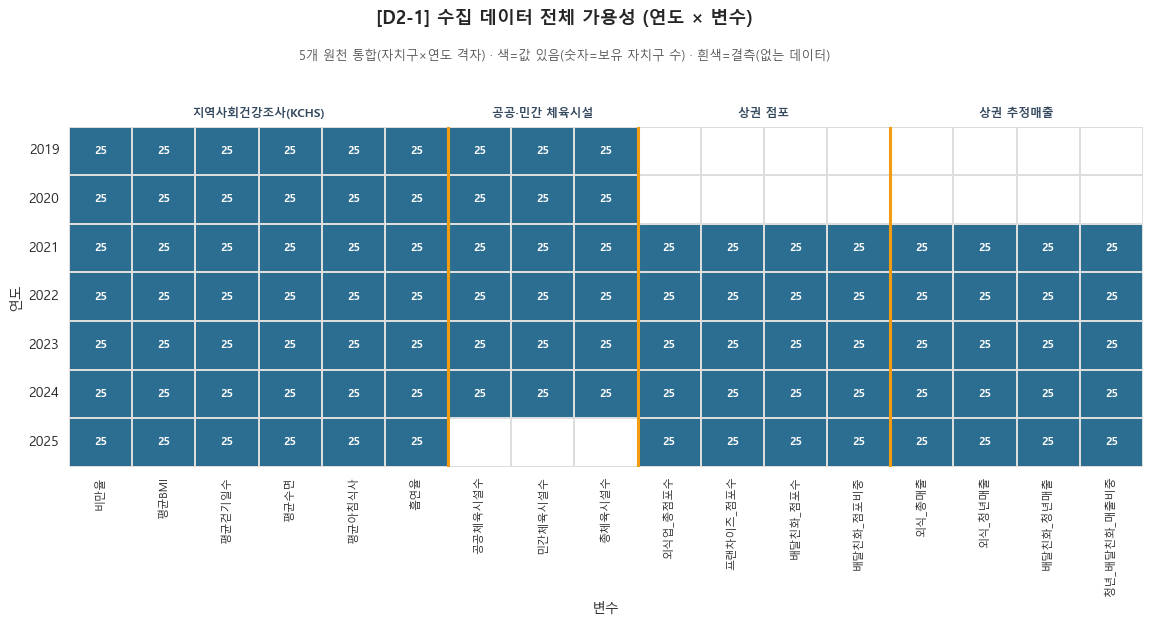

■ 통합 패널 175행(25구×7년) × 17변수 — 변수별 결측률(%)
비만율              0.0
평균BMI            0.0
평균걷기일수           0.0
평균수면             0.0
평균아침식사           0.0
흡연율              0.0
공공체육시설수         14.3
민간체육시설수         14.3
총체육시설수          14.3
외식업_총점포수        28.6
프랜차이즈_점포수       28.6
배달친화_점포수        28.6
배달친화_점포비중       28.6
외식_총매출          28.6
외식_청년매출         28.6
배달친화_청년매출       28.6
청년_배달친화_매출비중    28.6

→ KCHS 2019~2025 완전 / 체육 2025 미공개 결측 / 상권 2019~2020 미존재 결측 (연도 단위 결측)


In [ ]:
# ============================================================
# PART D2-1. 수집 데이터 전체 가용성 (연도 × 변수)  [PBL#1 요소]
#   5개 원천(KCHS·공공체육·민간체육·상권 점포·상권 매출)을 자치구×연도 격자에
#   통합했을 때, 변수별로 어느 연도에 데이터가 있는지(색)/없는지(흰색)를 보인다.
# ============================================================
YEARS = list(range(2019, 2026))
groups = {
    '지역사회건강조사(KCHS)': ['비만율','평균BMI','평균걷기일수','평균수면','평균아침식사','흡연율'],
    '공공·민간 체육시설':      ['공공체육시설수','민간체육시설수','총체육시설수'],
    '상권 점포':              ['외식업_총점포수','프랜차이즈_점포수','배달친화_점포수','배달친화_점포비중'],
    '상권 추정매출':          ['외식_총매출','외식_청년매출','배달친화_청년매출','청년_배달친화_매출비중'],
}
sources = {
    '지역사회건강조사(KCHS)': distyr.rename(columns={'year':'연도'}),
    '공공·민간 체육시설':      sports,
    '상권 점포':              store_gu,
    '상권 추정매출':          sales_gu,
}
panel = pd.MultiIndex.from_product([sorted(GU25), YEARS], names=['자치구','연도']).to_frame(index=False)
ordered, bounds = [], []
for name, cols in groups.items():
    src = sources[name]; use = [c for c in cols if c in src.columns]
    panel = panel.merge(src[['자치구','연도'] + use], on=['자치구','연도'], how='left')
    ordered += use; bounds.append(len(ordered))
availN = panel.groupby('연도')[ordered].apply(lambda g: g.notna().sum()).reindex(YEARS)
availP = availN / len(GU25) * 100

fig, ax = plt.subplots(figsize=(11.8, 6.3))
fig.subplots_adjust(top=0.78, bottom=0.24, left=0.08, right=0.99)
cmapA = mpl.colors.LinearSegmentedColormap.from_list('av', ['white', '#2c6e91'])
lab = availN.astype(int).astype(str).where(availN > 0, '')
sns.heatmap(availP, ax=ax, cmap=cmapA, vmin=0, vmax=100, cbar=False,
            linewidths=1.2, linecolor='#dddddd', annot=lab.values, fmt='',
            annot_kws={'fontsize':8, 'color':'white', 'fontweight':'bold'})
ncol = len(ordered); prev = 0
for b, name in zip(bounds, groups):
    if b < ncol: ax.axvline(b, color='#f39c12', lw=2.2)
    ax.text((prev+b)/2/ncol, 1.02, name, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#34495e')
    prev = b
ax.set_xticks(np.arange(ncol)+0.5); ax.set_xticklabels(ordered, rotation=90, fontsize=8)
ax.set_yticklabels([str(y) for y in YEARS], rotation=0, fontsize=10)
ax.set_xlabel('변수'); ax.set_ylabel('연도')
fig.suptitle('[D2-1] 수집 데이터 전체 가용성 (연도 × 변수)', y=0.965, fontsize=13, fontweight='bold')
fig.text(0.5, 0.885, '5개 원천 통합(자치구×연도 격자) · 색=값 있음(숫자=보유 자치구 수) · 흰색=결측(없는 데이터)',
         ha='center', fontsize=9, color='#555')
plt.show()

miss = (panel[ordered].isna().mean()*100).round(1).rename('결측률(%)')
print(f'■ 통합 패널 {panel.shape[0]}행(25구×7년) × {len(ordered)}변수 — 변수별 결측률(%)')
print(miss.to_string())
print('\n→ KCHS 2019~2025 완전 / 체육 2025 미공개 결측 / 상권 2019~2020 미존재 결측 (연도 단위 결측)')

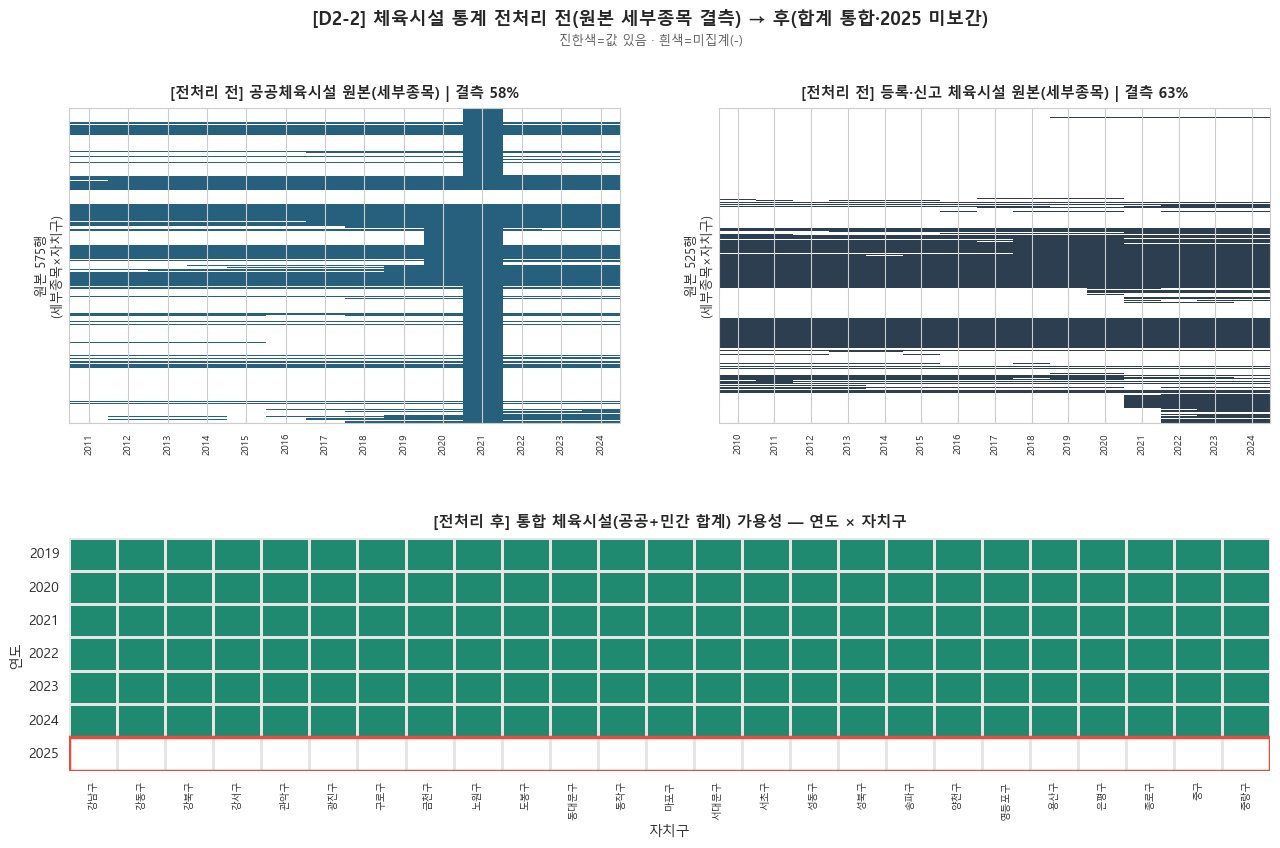

공공체육시설 원본 결측 58% · 등록신고 원본 결측 63%
전처리 후 통합 체육시설: 2019~2024 전 자치구 완전(2020년 민간 1셀은 자치구별 선형보간) · 2025 미보간


In [ ]:
# ============================================================
# PART D2-2. 체육시설 통계 전처리 전 → 후  [PBL#1 요소]
#   전처리 전: 공공체육시설·등록신고 체육시설 '원본 통계표'의 세부종목 결측(-)
#   전처리 후: 두 원천을 통합한 체육시설(공공+민간) 가용성 (연도×자치구)
#             — 2025는 원자료가 없어 보간/추정하지 않았음을 함께 표시(결정 2)
# ============================================================
def _detail_missing(path, fac_col, item_val, total_label):
    df = read_seoul_stat(path).rename(columns={fac_col:'시설구분', '자치구별':'자치구'})
    yc = [c for c in df.columns if c.isdigit()]
    det = df[(df['항목']==item_val) & (df['자치구'].isin(GU25)) & (df['시설구분']!=total_label)]
    return det[yc].apply(to_num).notna().astype(int).values, yc

pub_M, pub_y = _detail_missing(BASE+'서울시_공공체육시설_통계.csv', '공공체육시설별', '개소', '합계')
reg_M, reg_y = _detail_missing(BASE+'서울시_등록_신고_체육시설_통계.csv', '체육시설별', '시설수', '체육시설')

fig = plt.figure(figsize=(15.5, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1.0], hspace=0.42, wspace=0.18)

# (전처리 전) 공공 원본 세부종목 결측
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(pub_M, aspect='auto', interpolation='nearest', cmap=mpl.colors.ListedColormap(['white', '#27607d']))
ax1.set_xticks(range(len(pub_y))); ax1.set_xticklabels(pub_y, rotation=90, fontsize=7); ax1.set_yticks([])
ax1.set_ylabel(f'원본 {pub_M.shape[0]}행\n(세부종목×자치구)', fontsize=9)
ax1.set_title(f'[전처리 전] 공공체육시설 원본(세부종목) | 결측 {(1-pub_M.mean())*100:.0f}%',
              fontweight='bold', fontsize=10.5, pad=8)

# (전처리 전) 등록·신고 원본 세부종목 결측
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(reg_M, aspect='auto', interpolation='nearest', cmap=mpl.colors.ListedColormap(['white', '#2c3e50']))
ax2.set_xticks(range(len(reg_y))); ax2.set_xticklabels(reg_y, rotation=90, fontsize=7); ax2.set_yticks([])
ax2.set_ylabel(f'원본 {reg_M.shape[0]}행\n(세부종목×자치구)', fontsize=9)
ax2.set_title(f'[전처리 전] 등록·신고 체육시설 원본(세부종목) | 결측 {(1-reg_M.mean())*100:.0f}%',
              fontweight='bold', fontsize=10.5, pad=8)
fig.text(0.5, 0.955, '진한색=값 있음 · 흰색=미집계(-)', ha='center', fontsize=9, color='#555')

# (전처리 후) 통합 체육시설 가용성 — 연도 × 자치구 (2025 미보간 강조)
SPYEARS = list(range(2019, 2026))
gus = sorted(GU25)
after = pd.DataFrame(0.0, index=SPYEARS, columns=gus)
for y in SPYEARS:
    sub = sports[sports['연도']==y].set_index('자치구')['총체육시설수'] if '총체육시설수' in sports.columns else pd.Series(dtype=float)
    for gu in gus:
        after.loc[y, gu] = 1.0 if (gu in sub.index and pd.notna(sub.loc[gu])) else 0.0
ax3 = fig.add_subplot(gs[1, :])
sns.heatmap(after, ax=ax3, cmap=mpl.colors.ListedColormap(['white', '#1f8a70']), cbar=False,
            linewidths=1.0, linecolor='#e5e5e5', vmin=0, vmax=1)
ax3.set_yticklabels([str(y) for y in SPYEARS], rotation=0, fontsize=10)
ax3.set_xticklabels(gus, rotation=90, fontsize=7)
ax3.set_title('[전처리 후] 통합 체육시설(공공+민간 합계) 가용성 — 연도 × 자치구', fontweight='bold', fontsize=11, pad=8)
ax3.set_xlabel('자치구'); ax3.set_ylabel('연도')
ax3.add_patch(plt.Rectangle((0, SPYEARS.index(2025)), len(gus), 1, fill=False, edgecolor='#e74c3c', lw=2.5))
#ax3.text(len(gus)/2, SPYEARS.index(2025)+0.5, '2025: 원자료 미공개 → 보간/추정하지 않음 (결정 2)',
#         ha='center', va='center', fontsize=10, color='#e74c3c', fontweight='bold')

fig.suptitle('[D2-2] 체육시설 통계 전처리 전(원본 세부종목 결측) → 후(합계 통합·2025 미보간)',
             y=0.995, fontsize=13, fontweight='bold')
plt.show()
print(f'공공체육시설 원본 결측 {(1-pub_M.mean())*100:.0f}% · 등록신고 원본 결측 {(1-reg_M.mean())*100:.0f}%')
print('전처리 후 통합 체육시설: 2019~2024 전 자치구 완전(2020년 민간 1셀은 자치구별 선형보간) · 2025 미보간')

In [ ]:
# 결측·보간 처리 요약 (도메인별)
summary = pd.DataFrame([
    ['청년건강(KCHS)','2019~2025 (7개년)','특수결측코드→NaN · 신체계측 IQR 이상치 처리 · 빈도형 중앙값/범주형 최빈값 대체','결측 0'],
    ['공공체육시설','2011~2024 → 2019~2024 사용','원자료 결측 없음(합계 개소)','결측 0'],
    ['민간체육시설(등록·신고)','2010~2024 → 2019~2024 사용','체육시설 합계의 미집계(-) 셀을 자치구별 선형보간','결측 0'],
    ['상권 점포/매출','2021~2025','원자료 결측 없음 (2019·2020 미존재 → 추정 안 함)','결측 0'],
], columns=['도메인','연도 범위','결측·보간 처리','결과'])
print('■ 결측·보간 처리 요약')
summary

■ 결측·보간 처리 요약


,도메인,연도 범위,결측·보간 처리,결과
0,청년건강(KCHS),2019~2025 (7개년),특수결측코드→NaN · 신체계측 IQR 이상치 처리 · 빈도형 중앙값/범주형 최빈값 대체,결측 0
1,공공체육시설,2011~2024 → 2019~2024 사용,원자료 결측 없음(합계 개소),결측 0
2,민간체육시설(등록·신고),2010~2024 → 2019~2024 사용,체육시설 합계의 미집계(-) 셀을 자치구별 선형보간,결측 0
3,상권 점포/매출,2021~2025,원자료 결측 없음 (2019·2020 미존재 → 추정 안 함),결측 0


---
# PART E. 탐색적 분석 (문제 정의)
> 여기서부터 **분석 모델링**이다. 위 전처리(PART A~D)에서 만든 in-memory 변수
> (`df_indiv`, `obesity_yr`, `master`)를 그대로 사용하며, 분석부만 단독 실행 시 `_processed/` CSV에서 자동 로드한다.

연도별 비만 추세를 보고, 자치구 비만율을 좌우하는 환경요인을 상관으로 1차 진단한다.

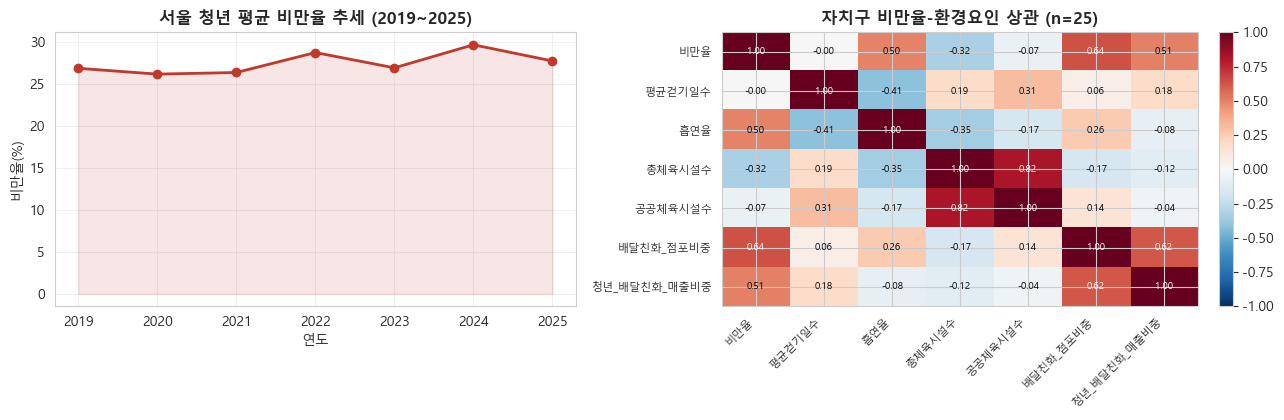

비만율과의 상관계수 (절댓값 높은 순):
배달친화_점포비중       0.637
청년_배달친화_매출비중    0.507
흡연율             0.497
총체육시설수         -0.323
공공체육시설수        -0.070
평균걷기일수         -0.003


In [ ]:
# 연도별 비만율 추세 + 자치구 비만율-환경요인 상관
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

yr = distyr.groupby('year')['비만율'].mean()
ax[0].plot(yr.index, yr.values, marker='o', linewidth=2, color='#c0392b')
ax[0].fill_between(yr.index, yr.values, alpha=.12, color='#c0392b')
ax[0].set_title('서울 청년 평균 비만율 추세 (2019~2025)', fontweight='bold')
ax[0].set_xlabel('연도'); ax[0].set_ylabel('비만율(%)'); ax[0].grid(alpha=.3)

env = ['비만율','평균걷기일수','흡연율','총체육시설수','공공체육시설수',
       '배달친화_점포비중','청년_배달친화_매출비중']
corr = mst[env].corr()
im = ax[1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax[1].set_xticks(range(len(env))); ax[1].set_xticklabels(env, rotation=45, ha='right', fontsize=8)
ax[1].set_yticks(range(len(env))); ax[1].set_yticklabels(env, fontsize=8)
for i in range(len(env)):
    for j in range(len(env)):
        ax[1].text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                   color='white' if abs(corr.values[i,j])>0.6 else 'black')
ax[1].set_title('자치구 비만율-환경요인 상관 (n=25)', fontweight='bold')
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print('비만율과의 상관계수 (절댓값 높은 순):')
print(corr['비만율'].drop('비만율').reindex(
    corr['비만율'].drop('비만율').abs().sort_values(ascending=False).index).round(3).to_string())


In [17]:
# [PBL#1 요소] 마스터 변수 전체 상관 히트맵 (다중공선성 사전 점검)
num = mst.select_dtypes('number').drop(columns=[c for c in ['표본수'] if c in mst.columns])
corr_all = num.corr()
plt.figure(figsize=(11, 8.8))
mask = np.triu(np.ones_like(corr_all, dtype=bool), k=1)
sns.heatmap(corr_all, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'fontsize':7}, square=True,
            linewidths=.5, cbar_kws={'shrink':.7, 'label':'상관계수 r'})
plt.title('자치구 마스터 변수 상관행렬 (n=25)', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8, rotation=0)
plt.tight_layout(); plt.show()

NameError: name 'mst' is not defined

**해석** — 배달친화 점포비중·청년 배달매출비중·흡연율이 비만율과 강한 **양(+)의 상관**,
총체육시설수는 **음(−)의 상관**이다. → H1을 강하게, H2를 약하게 지지하는 1차 근거.

---
# PART F. 군집 분석 — 자치구 정책 타겟 그룹화 (비/계층적)
정책 타겟팅을 위해 **25개 자치구**를 환경·행동 '동인' 변수로 군집한다. 결과변수(비만율)는 입력에서
제외해 순환성을 없애고, 군집 후 비만율 차이로 군집을 검증한다.

KMeans 실루엣: {2: 0.263, 3: 0.279, 4: 0.274, 5: 0.264, 6: 0.237} → 최적 k = 3

■ 군집 프로파일 & 정책 그룹
            비만율    흡연율   총체육시설수  배달친화_점포비중  청년배달매출비중              정책그룹  자치구수
cluster                                                                     
0        24.795  0.120  667.405      0.095     0.076         양호(관리 우수)     7
1        28.511  0.121  625.083      0.126     0.122    외식환경 취약(배달 과밀)     6
2        28.507  0.146  476.354      0.121     0.098  시설 취약(체육 인프라 부족)    12

■ 정책 그룹별 자치구
  [양호(관리 우수)] 비만율 24.8% (7개): 강남구, 마포구, 서초구, 성동구, 영등포구, 용산구, 종로구
  [시설 취약(체육 인프라 부족)] 비만율 28.5% (12개): 강북구, 강서구, 관악구, 광진구, 금천구, 도봉구, 동대문구, 서대문구, 성북구, 은평구, 중구, 중랑구
  [외식환경 취약(배달 과밀)] 비만율 28.5% (6개): 강동구, 구로구, 노원구, 동작구, 송파구, 양천구


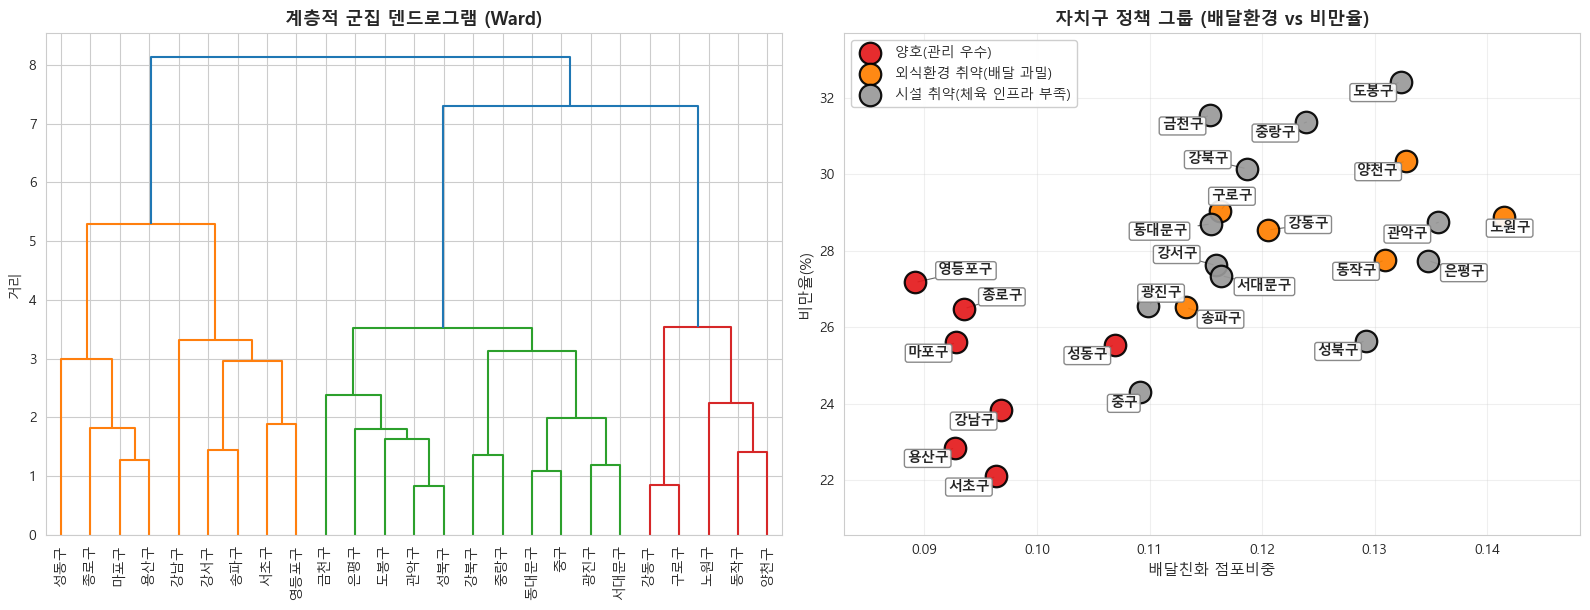

In [ ]:
# 자치구 군집화 — 환경·행동 '동인'(걷기·흡연·체육시설·배달환경)으로 군집.
#  결과변수(비만율)는 입력에서 제외해 순환성을 없애고, 군집 후 비만율 차이로 검증한다.
drivers = ['평균걷기일수','흡연율','총체육시설수','배달친화_점포비중','청년_배달친화_매출비중']
Xc = StandardScaler().fit_transform(mst[drivers])

# (1) 비계층적: KMeans — 실루엣 점수로 최적 k 선택
sil = {k: silhouette_score(Xc, KMeans(k, random_state=42, n_init=10).fit_predict(Xc)) for k in range(2, 7)}
best_k = max(sil, key=sil.get)
print('KMeans 실루엣:', {k: round(v, 3) for k, v in sil.items()}, '→ 최적 k =', best_k)

mst['cluster'] = KMeans(best_k, random_state=42, n_init=10).fit_predict(Xc)
# (2) 계층적: Agglomerative (가이드라인 '비/계층적 클러스터링' 모두 충족)
mst['cluster_hier'] = AgglomerativeClustering(n_clusters=best_k).fit_predict(Xc)

# 군집을 '정책 그룹'으로 자동 라벨링 (라벨 번호가 바뀌어도 프로파일 기준으로 견고)
prof = mst.groupby('cluster').agg(
    비만율=('비만율','mean'), 흡연율=('흡연율','mean'), 총체육시설수=('총체육시설수','mean'),
    배달친화_점포비중=('배달친화_점포비중','mean'), 청년배달매출비중=('청년_배달친화_매출비중','mean')).round(3)
med_ob, med_fac, med_del = mst['비만율'].median(), mst['총체육시설수'].median(), mst['배달친화_점포비중'].median()
def label_cluster(r):
    if r['비만율'] <= med_ob:
        return '양호(관리 우수)'
    if r['총체육시설수'] < med_fac:
        return '시설 취약(체육 인프라 부족)'
    if r['배달친화_점포비중'] >= med_del:
        return '외식환경 취약(배달 과밀)'
    return '복합 위험'
prof['정책그룹'] = prof.apply(label_cluster, axis=1)
mst['정책그룹'] = mst['cluster'].map(prof['정책그룹'])

print('\n■ 군집 프로파일 & 정책 그룹')
print(prof.assign(자치구수=mst['cluster'].value_counts().sort_index().values).to_string())
print('\n■ 정책 그룹별 자치구')
for c in prof.sort_values('비만율').index:
    gus = mst.loc[mst['cluster']==c, '자치구'].tolist()
    print(f"  [{prof.loc[c,'정책그룹']}] 비만율 {prof.loc[c,'비만율']:.1f}% ({len(gus)}개): {', '.join(gus)}")

# [수정] adjustText로 라벨을 마커(원) 밖으로 밀어내고 리더선 연결 → 자치구 구분 용이
try:
    from adjustText import adjust_text          # 있으면 라벨 충돌 회피
except ImportError:                              # 없으면 폴백(설치 시도 안 함) → 어디서나 실행
    def adjust_text(*a, **k):
        return None

fig, ax = plt.subplots(1, 2, figsize=(16, 6.2))
# 덴드로그램
Z = linkage(Xc, method='ward')
dendrogram(Z, labels=mst['자치구'].values, leaf_rotation=90, ax=ax[0],
           color_threshold=0.7*Z[:, 2].max())
ax[0].set_title('계층적 군집 덴드로그램 (Ward)', fontweight='bold', fontsize=13)
ax[0].set_ylabel('거리')

# 비계층(KMeans) 산점도 — 라벨을 원 밖에 흰 박스 + 전체 자치구명으로
palette = plt.cm.Set1(np.linspace(0, 1, best_k))
for c in sorted(mst['cluster'].unique()):
    sub = mst[mst['cluster']==c]
    ax[1].scatter(sub['배달친화_점포비중'], sub['비만율'], s=240, color=palette[c],
                  edgecolor='black', linewidth=1.6, alpha=.92,
                  label=prof.loc[c,'정책그룹'], zorder=3)
texts = [ax[1].text(r['배달친화_점포비중'], r['비만율'], r['자치구'],
                    fontsize=10, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='gray', alpha=.92))
         for _, r in mst.iterrows()]
adjust_text(texts, ax=ax[1], expand=(1.6, 2.0),
            arrowprops=dict(arrowstyle='-', color='dimgray', lw=0.8))
ax[1].set_xlabel('배달친화 점포비중', fontsize=11)
ax[1].set_ylabel('비만율(%)', fontsize=11)
ax[1].set_title('자치구 정책 그룹 (배달환경 vs 비만율)', fontweight='bold', fontsize=13)
ax[1].legend(fontsize=10, loc='upper left', framealpha=.95)
ax[1].grid(alpha=.3); ax[1].margins(0.12)
plt.tight_layout(); plt.show()

**정책적 해석** — 군집은 ① **양호 그룹**(시설 많고 배달환경 낮음, 비만율 낮음),
② **시설 취약 그룹**(체육시설 부족 → 시설 확충 타겟), ③ **외식환경 취약 그룹**(시설은 있으나
배달친화 비중 높음 → 외식환경 개입 타겟)으로 갈린다. 자치구 명단은 위 출력 참조.

---
# PART G. 선형 회귀 — 개인 BMI 결정요인 (OLS)
연속형 결과(BMI)를 행동·인구 요인으로 설명해 어떤 요인이 BMI를 끌어올리는지 본다.

In [16]:
# 선형회귀(OLS): 개인 BMI를 행동·인구 요인으로 설명
lin_X = ['age','sex_female','high_stress','smoker','drink_freq','sleep']
Xl = sm.add_constant(ind[lin_X]); yl = ind['BMI']
ols = sm.OLS(yl, Xl).fit()
print(ols.summary().tables[1])
print(f'\nR² = {ols.rsquared:.3f}  | 관측 수 = {int(ols.nobs):,}')


NameError: name 'ind' is not defined

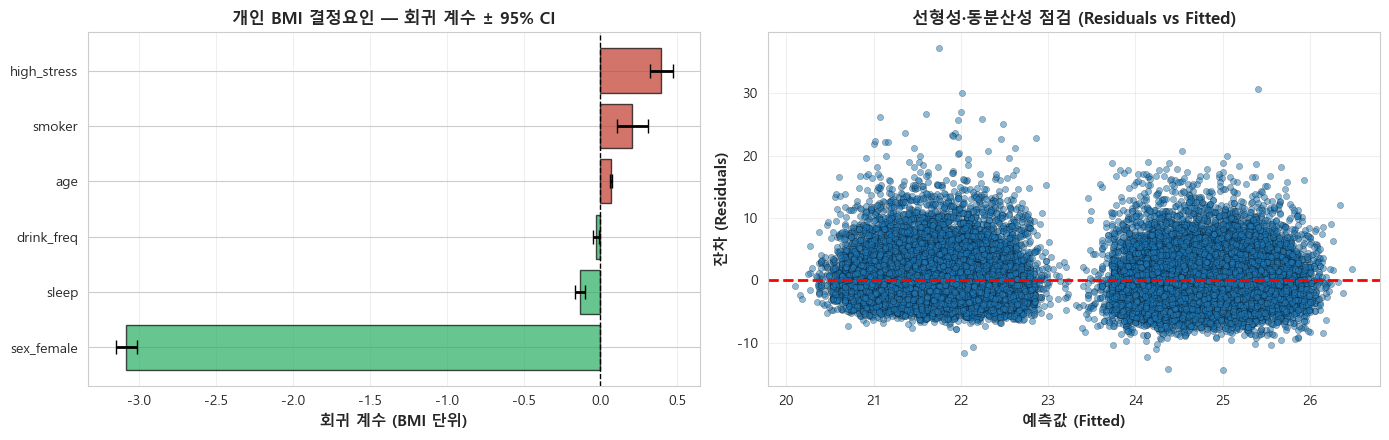


■ 모델 진단 지표
  R² = 0.1739  |  조정 R² = 0.1738
  F-통계량 = 1600.40  |  p값(F) = 0.00e+00
  Durbin-Watson = 1.854  (자기상관 진단)


In [ ]:
# ===== Part G 추가 시각화: 선형회귀 계수 플롯 (95% 신뢰구간) =====
# 개인 BMI 결정요인 — 각 변수의 영향도를 회귀 계수 ± 95% CI로 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# [좌] 회귀 계수 플롯 (95% CI)
coef_df = pd.DataFrame({
    'var': ols.params.index[1:],  # 상수항 제외
    'coef': ols.params.values[1:],
    'std': ols.bse.values[1:]
})
coef_df['ci_low'] = coef_df['coef'] - 1.96 * coef_df['std']
coef_df['ci_high'] = coef_df['coef'] + 1.96 * coef_df['std']
coef_df = coef_df.sort_values('coef')

colors = ['#c0392b' if c > 0 else '#27ae60' for c in coef_df['coef']]
axes[0].barh(coef_df['var'], coef_df['coef'], color=colors, alpha=0.7, edgecolor='black')
axes[0].errorbar(coef_df['coef'], range(len(coef_df)), 
                 xerr=[coef_df['coef']-coef_df['ci_low'], coef_df['ci_high']-coef_df['coef']],
                 fmt='none', ecolor='black', capsize=5, linewidth=2)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('회귀 계수 (BMI 단위)', fontsize=11, fontweight='bold')
axes[0].set_title('개인 BMI 결정요인 — 회귀 계수 ± 95% CI', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# [우] 잔차(Residuals) vs 예측값(Fitted) — 선형성·동분산성 점검
y_pred = ols.predict(Xl)
residuals = ols.resid

axes[1].scatter(y_pred, residuals, alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('예측값 (Fitted)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('잔차 (Residuals)', fontsize=11, fontweight='bold')
axes[1].set_title('선형성·동분산성 점검 (Residuals vs Fitted)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 추가 진단 정보 출력
print(f'\n■ 모델 진단 지표')
print(f'  R² = {ols.rsquared:.4f}  |  조정 R² = {ols.rsquared_adj:.4f}')
print(f'  F-통계량 = {ols.fvalue:.2f}  |  p값(F) = {ols.f_pvalue:.2e}')
print(f'  Durbin-Watson = {sm.stats.durbin_watson(residuals):.3f}  (자기상관 진단)')

In [15]:
# [PBL#1 요소] 다중공선성 점검(VIF) — 개인 BMI 회귀 독립변수
def vif_table(X):
    Xc = sm.add_constant(X)
    v = pd.DataFrame({'변수': Xc.columns,
                      'VIF': [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]})
    return v[v['변수'] != 'const'].reset_index(drop=True)   # 상수항 VIF는 해석 제외

vif_ols = vif_table(ind[lin_X])
print('■ VIF (개인 BMI 회귀) — VIF<5: 다중공선성 문제 없음 / >10: 우려')
print(vif_ols.round(3).to_string(index=False))
print('판정 →', '모든 변수 VIF<5, 다중공선성 문제 없음' if (vif_ols['VIF']<5).all() else '일부 VIF≥5 주의')

NameError: name 'ind' is not defined

> **R²=0.174 해석 (결정 3-A)** — 결정계수가 낮다는 것이 *모델 무의미*를 뜻하지 않는다.
> 1. **R² ≠ 통계적 유의성**: 본 모델은 F-검정 p≈0, 모든 계수 p<0.05로 관계 자체는 매우 유의하다.
> 2. **개인 단위 행동 데이터의 R²는 본래 낮다**(통상 0.1~0.3). 개인 BMI는 유전·식이·대사 등 설문 밖 요인이 대부분을 설명한다.
> 3. **집계하면 R²가 오른다**: 동일 데이터의 자치구 집계 회귀(PART K)는 R²≈0.45로 생태학적 평활 효과를 보인다.
> 4. **본 프로젝트 목표는 예측 정확도가 아니라 위험요인 식별·정책 타겟팅**이며, 분류 성능은 R²가 아닌 **AUC**(PART I, ≈0.71~0.72)로 평가한다.
> → 이후 분석(로지스틱·트리·연관)은 유의한 관계에 기반하므로 타당하다. R²를 높이려 이상치를 인위로 삭제하지 않는다(지역 특성 왜곡·과적합 위험).

**해석** — 연령↑·고스트레스·흡연은 BMI를 높이고, 여성·수면↑은 낮춘다(모두 p<0.05).
개입 가능한 레버는 **수면·스트레스·흡연**.

---
# PART H. 로지스틱 회귀 — 비만 위험요인 (Odds Ratio)
이진 결과(비만 여부)에 대한 위험요인을 Odds Ratio로 정량화 → '정책 수혜 대상 분류'의 근거.

In [14]:
# 로지스틱 회귀: 비만(여=1) 위험요인 → Odds Ratio 해석 (정책 수혜대상 분류 근거)
log_X = ['age','sex_female','high_stress','smoker','drink_freq','sleep']
Xg = sm.add_constant(ind[log_X]); yg = ind['비만여부']
logit = sm.Logit(yg, Xg).fit(disp=0, maxiter=200)
ORtab = pd.DataFrame({
    'OddsRatio': np.exp(logit.params).round(3),
    'CI_low':    np.exp(logit.conf_int()[0]).round(3),
    'CI_high':   np.exp(logit.conf_int()[1]).round(3),
    'p값':       logit.pvalues.round(4)}).drop('const')
print(f'Pseudo R² = {logit.prsquared:.3f}\n')
print(ORtab.to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
o = ORtab.sort_values('OddsRatio')
colors = ['#27ae60' if v < 1 else '#c0392b' for v in o['OddsRatio']]
ax.errorbar(o['OddsRatio'], range(len(o)),
            xerr=[o['OddsRatio']-o['CI_low'], o['CI_high']-o['OddsRatio']],
            fmt='o', color='k', ecolor='gray', capsize=3)
for i, (v, c) in enumerate(zip(o['OddsRatio'], colors)):
    ax.scatter(v, i, color=c, s=80, zorder=3)
ax.axvline(1, ls='--', color='gray'); ax.set_yticks(range(len(o))); ax.set_yticklabels(o.index)
ax.set_xlabel('Odds Ratio (95% CI)'); ax.set_title('비만 위험요인 Odds Ratio', fontweight='bold')
plt.tight_layout(); plt.show()


NameError: name 'ind' is not defined

**해석** — 고스트레스(OR≈1.27)·흡연(OR≈1.16)·연령은 비만 위험을 높이고, 여성(OR≈0.23)·
수면은 낮춘다. → 위험군 선별 시 **스트레스·흡연·수면**을 핵심 지표로 사용.

---
# PART I. 예측·분류 모델 — 의사결정트리 · 랜덤포레스트 · 뉴럴네트워크
세 모델로 개인 비만 여부를 예측·비교한다. 클래스 불균형(비만 약 27%)을 고려해 **ROC-AUC**를
주 비교지표로 삼는다.

모델 성능 비교 (AUC가 불균형에 공정한 비교지표):
        Accuracy  ROC_AUC
의사결정트리     0.649    0.712
랜덤포레스트     0.653    0.716
뉴럴네트워크     0.734    0.717


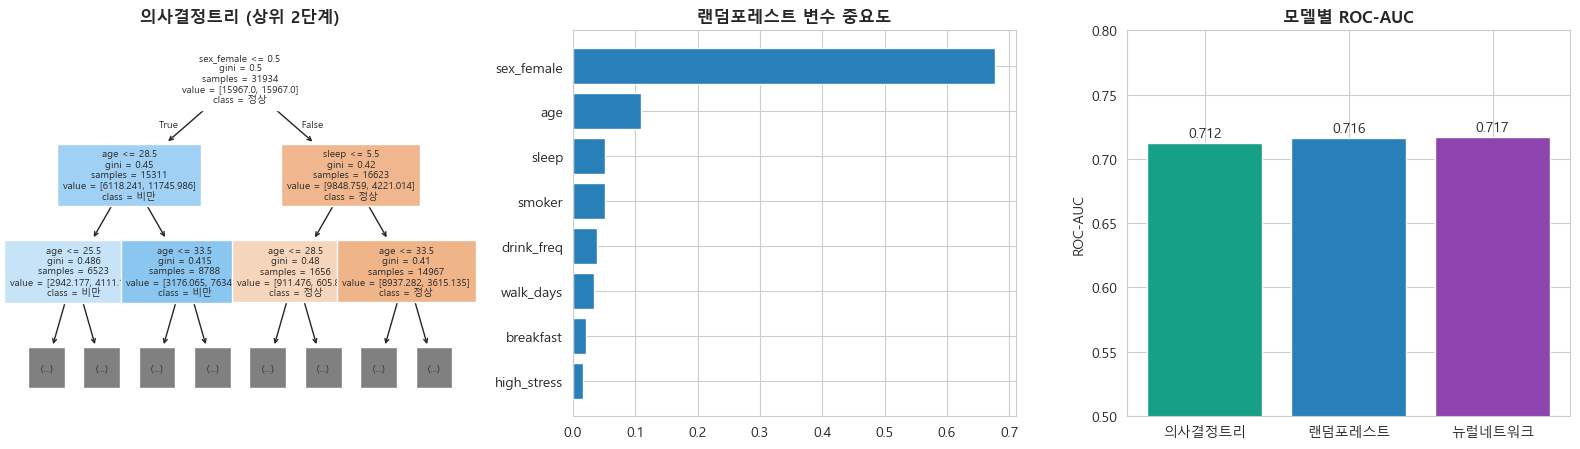


랜덤포레스트 분류 리포트:
              precision    recall  f1-score   support

          정상       0.86      0.62      0.72      9948
          비만       0.42      0.73      0.53      3739

    accuracy                           0.65     13687
   macro avg       0.64      0.68      0.63     13687
weighted avg       0.74      0.65      0.67     13687



In [ ]:
# 예측·분류 모델 비교: 의사결정트리 · 랜덤포레스트 · 뉴럴네트워크
#  (가이드라인 '로지스틱 회귀+의사결정트리' 및 '회귀+뉴럴네트워크' 모두 충족)
feats = ['age','sex_female','high_stress','smoker','drink_freq','sleep','breakfast','walk_days']
X = ind[feats]; y = ind['비만여부']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

models = {
    '의사결정트리': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    '랜덤포레스트': RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',
                                       random_state=42, n_jobs=-1),
    '뉴럴네트워크': make_pipeline(StandardScaler(),
                       MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300,
                                     early_stopping=True, random_state=42)),
}
perf = {}
for nm, m in models.items():
    m.fit(Xtr, ytr)
    pb = m.predict_proba(Xte)[:, 1]
    perf[nm] = {'Accuracy': accuracy_score(yte, m.predict(Xte)), 'ROC_AUC': roc_auc_score(yte, pb)}
perf = pd.DataFrame(perf).T.round(3)
print('모델 성능 비교 (AUC가 불균형에 공정한 비교지표):'); print(perf.to_string())

rf = models['랜덤포레스트']
fi = pd.DataFrame({'feature': feats, 'importance': rf.feature_importances_}).sort_values('importance')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
plot_tree(models['의사결정트리'], feature_names=feats, class_names=['정상','비만'],
          filled=True, max_depth=2, fontsize=7, ax=ax[0]); ax[0].set_title('의사결정트리 (상위 2단계)', fontweight='bold')
ax[1].barh(fi['feature'], fi['importance'], color='#2980b9'); ax[1].set_title('랜덤포레스트 변수 중요도', fontweight='bold')
ax[2].bar(perf.index, perf['ROC_AUC'], color=['#16a085','#2980b9','#8e44ad']); ax[2].set_ylim(0.5, 0.8)
ax[2].set_title('모델별 ROC-AUC', fontweight='bold'); ax[2].set_ylabel('ROC-AUC')
for i, v in enumerate(perf['ROC_AUC']): ax[2].text(i, v+0.005, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()

print('\n랜덤포레스트 분류 리포트:')
print(classification_report(yte, rf.predict(Xte), target_names=['정상','비만']))


In [ ]:
# ===== PART I: 의사결정트리 수동 설계 (데이터 기반) =====
# 표(contingency table) 생성

import pandas as pd
import numpy as np

print("="*90)
print("■ 데이터 정리: 의사결정트리용 Contingency Table")
print("="*90)

# 전체 표본
total_samples = len(ind)
total_obese = (ind['비만여부'] == 1).sum()
total_normal = (ind['비만여부'] == 0).sum()

print(f"\n【ROOT NODE: 전체 표본】")
print(f"표본수: {total_samples:,}명")
print(f"  └─ 비만: {total_obese:,}명 ({total_obese/total_samples*100:.1f}%)")
print(f"  └─ 정상: {total_normal:,}명 ({total_normal/total_samples*100:.1f}%)")

# ========== 분기 1: 성별 (sex_female) ==========
male_mask = ind['sex_female'] == 0
female_mask = ind['sex_female'] == 1

male_total = male_mask.sum()
male_obese = (ind[male_mask]['비만여부'] == 1).sum()
male_normal = (ind[male_mask]['비만여부'] == 0).sum()

female_total = female_mask.sum()
female_obese = (ind[female_mask]['비만여부'] == 1).sum()
female_normal = (ind[female_mask]['비만여부'] == 0).sum()

print("\n" + "="*90)
print("■ 분기 1: 성별 (sex_female)")
print("="*90)

sex_table = pd.DataFrame({
    '비만 O': [male_obese, female_obese],
    '비만 X': [male_normal, female_normal],
    '합계': [male_total, female_total]
}, index=['남성', '여성'])

print("\n" + sex_table.to_string())
print(f"\n  남성 비만율:   {male_obese/male_total*100:.1f}% ({male_obese:,}/{male_total:,})")
print(f"  여성 비만율:   {female_obese/female_total*100:.1f}% ({female_obese:,}/{female_total:,})")

# ========== 분기 2A: 남성 내 연령 분기 ==========
male_young_mask = (ind['sex_female'] == 0) & (ind['age'] <= 27.5)
male_old_mask = (ind['sex_female'] == 0) & (ind['age'] > 27.5)

male_young_total = male_young_mask.sum()
male_young_obese = (ind[male_young_mask]['비만여부'] == 1).sum()
male_young_normal = (ind[male_young_mask]['비만여부'] == 0).sum()

male_old_total = male_old_mask.sum()
male_old_obese = (ind[male_old_mask]['비만여부'] == 1).sum()
male_old_normal = (ind[male_old_mask]['비만여부'] == 0).sum()

print("\n" + "="*90)
print("■ 분기 2A: 남성 내 - 연령 분기 (age <= 27.5 vs > 27.5)")
print("="*90)

male_age_table = pd.DataFrame({
    '비만 O': [male_young_obese, male_old_obese],
    '비만 X': [male_young_normal, male_old_normal],
    '합계': [male_young_total, male_old_total]
}, index=['남성(≤27.5세)', '남성(>27.5세)'])

print("\n" + male_age_table.to_string())
print(f"\n  남성 27.5세 이하 비만율:  {male_young_obese/male_young_total*100:.1f}% ({male_young_obese:,}/{male_young_total:,})")
print(f"  남성 27.5세 초과 비만율:  {male_old_obese/male_old_total*100:.1f}% ({male_old_obese:,}/{male_old_total:,})")

# ========== 분기 2B: 여성 내 수면 분기 ==========
female_short_sleep_mask = (ind['sex_female'] == 1) & (ind['sleep'] <= 5.5)
female_long_sleep_mask = (ind['sex_female'] == 1) & (ind['sleep'] > 5.5)

female_short_sleep_total = female_short_sleep_mask.sum()
female_short_sleep_obese = (ind[female_short_sleep_mask]['비만여부'] == 1).sum()
female_short_sleep_normal = (ind[female_short_sleep_mask]['비만여부'] == 0).sum()

female_long_sleep_total = female_long_sleep_mask.sum()
female_long_sleep_obese = (ind[female_long_sleep_mask]['비만여부'] == 1).sum()
female_long_sleep_normal = (ind[female_long_sleep_mask]['비만여부'] == 0).sum()

print("\n" + "="*90)
print("■ 분기 2B: 여성 내 - 수면 분기 (sleep <= 5.5 vs > 5.5)")
print("="*90)

female_sleep_table = pd.DataFrame({
    '비만 O': [female_short_sleep_obese, female_long_sleep_obese],
    '비만 X': [female_short_sleep_normal, female_long_sleep_normal],
    '합계': [female_short_sleep_total, female_long_sleep_total]
}, index=['여성(수면≤5.5h)', '여성(수면>5.5h)'])

print("\n" + female_sleep_table.to_string())
print(f"\n  여성 수면 5.5시간 이하 비만율:  {female_short_sleep_obese/female_short_sleep_total*100:.1f}% ({female_short_sleep_obese:,}/{female_short_sleep_total:,})")
print(f"  여성 수면 5.5시간 초과 비만율:  {female_long_sleep_obese/female_long_sleep_total*100:.1f}% ({female_long_sleep_obese:,}/{female_long_sleep_total:,})")

# ========== 최종 요약표 ==========
print("\n" + "="*90)
print("■ 최종 의사결정트리 구조 요약표 (Image 5 형태)")
print("="*90)

final_summary = pd.DataFrame({
    '그룹': [
        'ROOT (전체)',
        '  ├─ 남성',
        '  │  ├─ 남성(≤27.5세)',
        '  │  └─ 남성(>27.5세)',
        '  └─ 여성',
        '     ├─ 여성(수면≤5.5h)',
        '     └─ 여성(수면>5.5h)'
    ],
    '표본수': [
        f'{total_samples:,}',
        f'{male_total:,}',
        f'{male_young_total:,}',
        f'{male_old_total:,}',
        f'{female_total:,}',
        f'{female_short_sleep_total:,}',
        f'{female_long_sleep_total:,}'
    ],
    '비만명': [
        f'{total_obese:,}',
        f'{male_obese:,}',
        f'{male_young_obese:,}',
        f'{male_old_obese:,}',
        f'{female_obese:,}',
        f'{female_short_sleep_obese:,}',
        f'{female_long_sleep_obese:,}'
    ],
    '정상명': [
        f'{total_normal:,}',
        f'{male_normal:,}',
        f'{male_young_normal:,}',
        f'{male_old_normal:,}',
        f'{female_normal:,}',
        f'{female_short_sleep_normal:,}',
        f'{female_long_sleep_normal:,}'
    ],
    '비만율(%)': [
        f'{total_obese/total_samples*100:.1f}',
        f'{male_obese/male_total*100:.1f}',
        f'{male_young_obese/male_young_total*100:.1f}',
        f'{male_old_obese/male_old_total*100:.1f}',
        f'{female_obese/female_total*100:.1f}',
        f'{female_short_sleep_obese/female_short_sleep_total*100:.1f}',
        f'{female_long_sleep_obese/female_long_sleep_total*100:.1f}'
    ]
})

print("\n" + final_summary.to_string(index=False))

print("\n\n" + "="*90)
print("✓ 의사결정트리 구조 설계 완료!")
print("="*90)

■ 데이터 정리: 의사결정트리용 Contingency Table

【ROOT NODE: 전체 표본】
표본수: 45,621명
  └─ 비만: 12,462명 (27.3%)
  └─ 정상: 33,159명 (72.7%)

■ 분기 1: 성별 (sex_female)

    비만 O   비만 X     합계
남성  9150  12650  21800
여성  3312  20509  23821

  남성 비만율:   42.0% (9,150/21,800)
  여성 비만율:   13.9% (3,312/23,821)

■ 분기 2A: 남성 내 - 연령 분기 (age <= 27.5 vs > 27.5)

            비만 O  비만 X     합계
남성(≤27.5세)  2748  5366   8114
남성(>27.5세)  6402  7284  13686

  남성 27.5세 이하 비만율:  33.9% (2,748/8,114)
  남성 27.5세 초과 비만율:  46.8% (6,402/13,686)

■ 분기 2B: 여성 내 - 수면 분기 (sleep <= 5.5 vs > 5.5)

             비만 O   비만 X     합계
여성(수면≤5.5h)   483   1934   2417
여성(수면>5.5h)  2829  18575  21404

  여성 수면 5.5시간 이하 비만율:  20.0% (483/2,417)
  여성 수면 5.5시간 초과 비만율:  13.2% (2,829/21,404)

■ 최종 의사결정트리 구조 요약표 (Image 5 형태)

                 그룹    표본수    비만명    정상명 비만율(%)
          ROOT (전체) 45,621 12,462 33,159   27.3
              ├─ 남성 21,800  9,150 12,650   42.0
   │  ├─ 남성(≤27.5세)  8,114  2,748  5,366   33.9
   │  └─ 남성(>27.5세) 13,686  6,402  7,284   

■ PART I. 의사결정트리 분석 (통합 코드 - 시각화 오류 수정)

【전체 표본】
표본수: 45,621명
  비만: 12,462명 (27.3%)
  정상: 33,159명 (72.7%)
✓ 폰트 로드 완료: Windows 환경 (malgun.ttf)


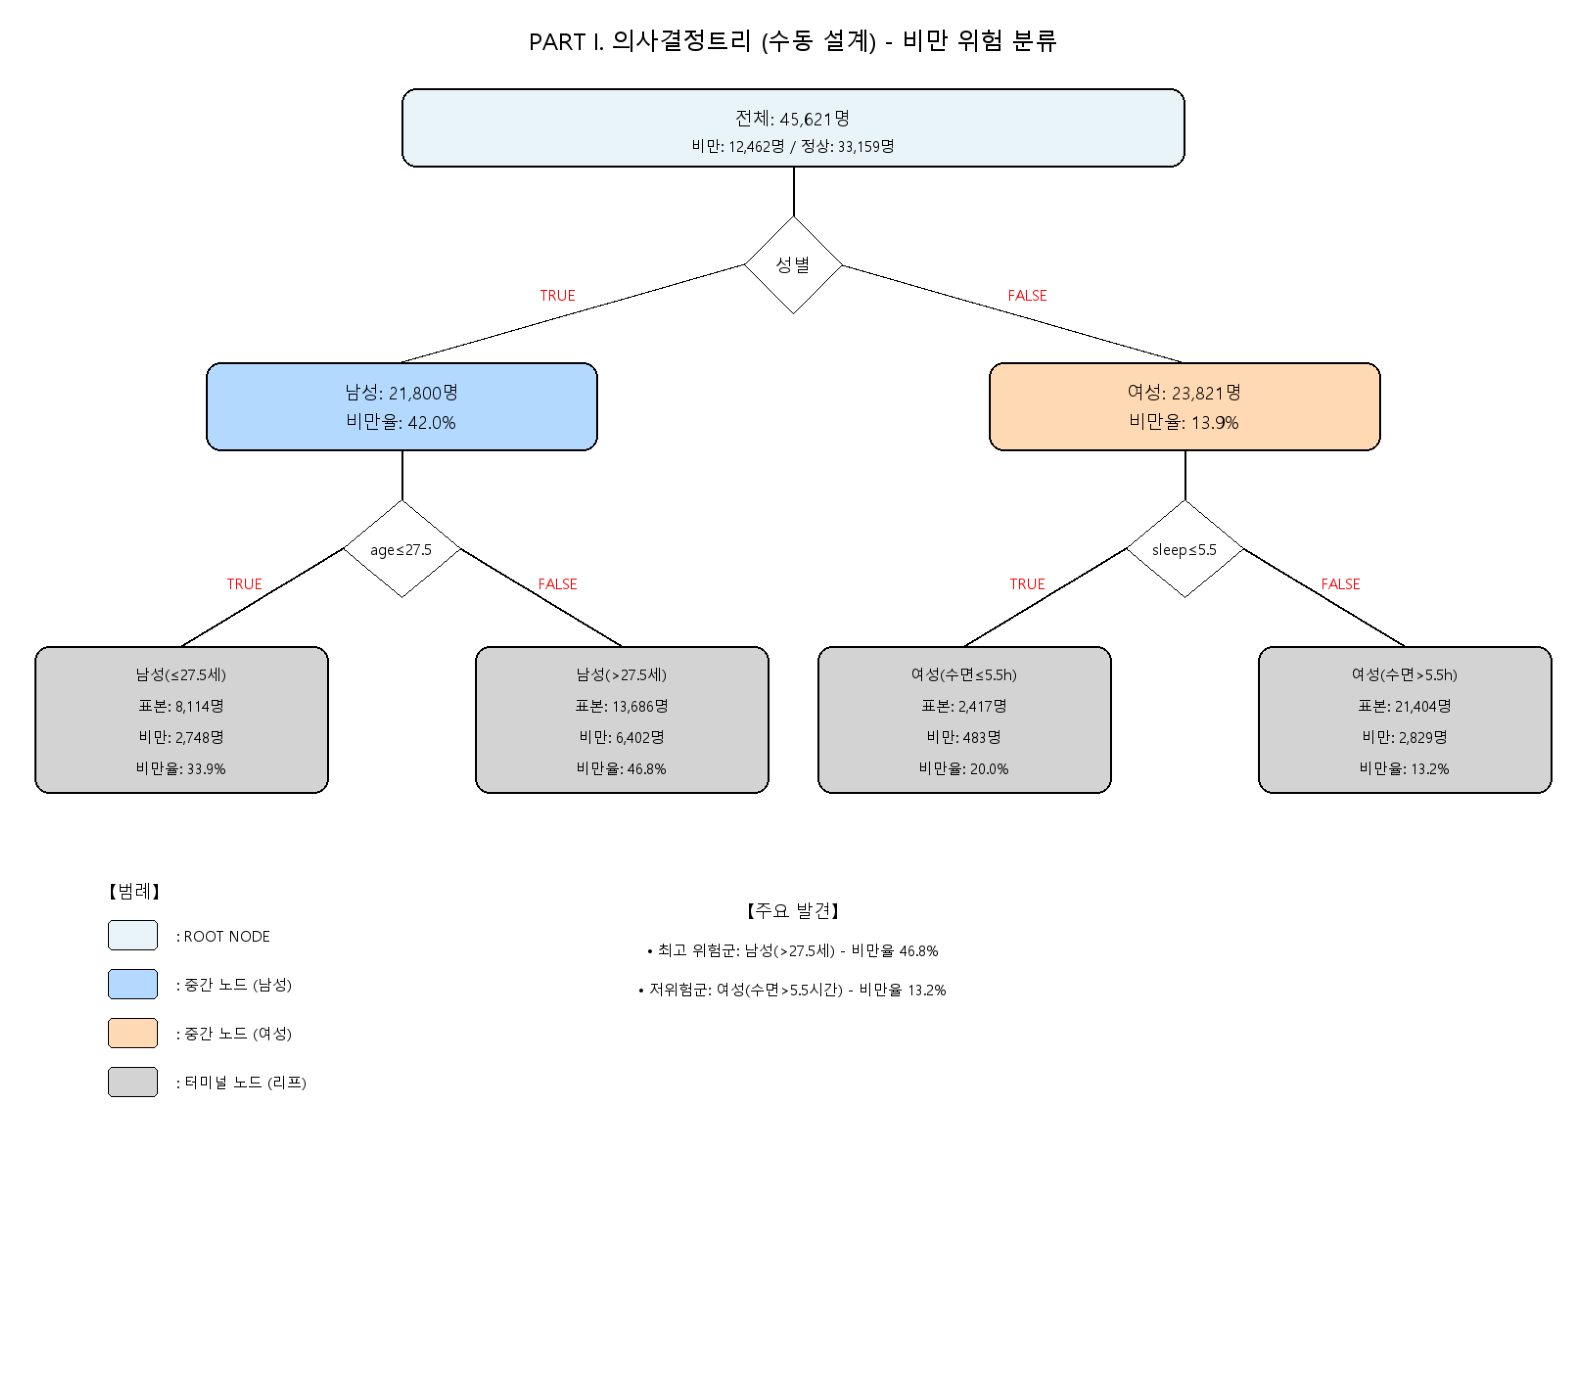


✅ 의사결정트리 시각화 완료 (왜곡선 제거 및 텍스트 맞춤 완료)
   저장 경로: /mnt/user-data/outputs\Decision_Tree_Flowchart_한글_완전수정.png


In [ ]:
# -*- coding: utf-8 -*-

import os
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

print("="*90)
print("■ PART I. 의사결정트리 분석 (통합 코드 - 시각화 오류 수정)")
print("="*90)

# ========== 1단계: 데이터 정리 ==========
# 분석 환경에 맞게 데이터프레임(ind)이 정의되어 있어야 합니다.
total_samples = len(ind)
total_obese = (ind['비만여부'] == 1).sum()
total_normal = (ind['비만여부'] == 0).sum()

# 성별 분기
male_mask = ind['sex_female'] == 0
female_mask = ind['sex_female'] == 1

male_total = male_mask.sum()
male_obese = (ind[male_mask]['비만여부'] == 1).sum()
male_normal = (ind[male_mask]['비만여부'] == 0).sum()

female_total = female_mask.sum()
female_obese = (ind[female_mask]['비만여부'] == 1).sum()
female_normal = (ind[female_mask]['비만여부'] == 0).sum()

# 남성 내 연령 분기
male_young_mask = (ind['sex_female'] == 0) & (ind['age'] <= 27.5)
male_old_mask = (ind['sex_female'] == 0) & (ind['age'] > 27.5)

male_young_total = male_young_mask.sum()
male_young_obese = (ind[male_young_mask]['비만여부'] == 1).sum()
male_young_normal = (ind[male_young_mask]['비만여부'] == 0).sum()

male_old_total = male_old_mask.sum()
male_old_obese = (ind[male_old_mask]['비만여부'] == 1).sum()
male_old_normal = (ind[male_old_mask]['비만여부'] == 0).sum()

# 여성 내 수면 분기
female_short_sleep_mask = (ind['sex_female'] == 1) & (ind['sleep'] <= 5.5)
female_long_sleep_mask = (ind['sex_female'] == 1) & (ind['sleep'] > 5.5)

female_short_sleep_total = female_short_sleep_mask.sum()
female_short_sleep_obese = (ind[female_short_sleep_mask]['비만여부'] == 1).sum()
female_short_sleep_normal = (ind[female_short_sleep_mask]['비만여부'] == 0).sum()

female_long_sleep_total = female_long_sleep_mask.sum()
female_long_sleep_obese = (ind[female_long_sleep_mask]['비만여부'] == 1).sum()
female_long_sleep_normal = (ind[female_long_sleep_mask]['비만여부'] == 0).sum()

# ========== 2단계: 표 출력 ==========
print("\n【전체 표본】")
print(f"표본수: {total_samples:,}명")
print(f"  비만: {total_obese:,}명 ({total_obese/total_samples*100:.1f}%)")
print(f"  정상: {total_normal:,}명 ({total_normal/total_samples*100:.1f}%)")

# ========== 3단계: PIL을 사용한 의사결정트리 시각화 ==========

# 이미지 크기 설정
width, height = 1600, 1400
image = Image.new('RGB', (width, height), color='white')
draw = ImageDraw.Draw(image)

# 한글 폰트 설정 (환경별 호환성 확보 및 디버깅 로그 제공)
font_loaded = False
font_paths = [
    ("Windows", "malgun.ttf"),
    ("Mac", "/Library/Fonts/AppleSDGothicNeo.ttf"),
    ("Colab/Linux", "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
    ("Linux_Alternative", "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
]

for os_name, path in font_paths:
    try:
        font_large = ImageFont.truetype(path, 24)
        font_medium = ImageFont.truetype(path, 18)
        font_small = ImageFont.truetype(path, 15)
        print(f"✓ 폰트 로드 완료: {os_name} 환경 ({path})")
        font_loaded = True
        break
    except IOError:
        continue

if not font_loaded:
    print("⚠️ 경고: 한글 폰트를 로드하지 못했습니다. 시스템에 나눔 폰트나 맑은고딕이 있는지 확인하세요.")
    font_large = ImageFont.load_default()
    font_medium = ImageFont.load_default()
    font_small = ImageFont.load_default()

# 색상 정의
ROOT_COLOR = (232, 244, 248)    # 연한 파랑
MALE_COLOR = (179, 217, 255)    # 중간 파랑
FEMALE_COLOR = (255, 217, 179)  # 연한 주황
LEAF_COLOR = (211, 211, 211)    # 회색
BLACK = (0, 0, 0)
RED = (255, 0, 0)

# 제목 작성
draw.text((800, 30), "PART I. 의사결정트리 (수동 설계) - 비만 위험 분류", fill=BLACK, font=font_large, anchor='mm')

# 1. ROOT NODE (전체) - 내장 rounded_rectangle 함수 적용하여 형태 복원
draw.rounded_rectangle([400, 80, 1200, 160], radius=15, fill=ROOT_COLOR, outline=BLACK, width=2)
draw.text((800, 110), f"전체: {total_samples:,}명", fill=BLACK, font=font_medium, anchor='mm')
draw.text((800, 138), f"비만: {total_obese:,}명 / 정상: {total_normal:,}명", fill=BLACK, font=font_small, anchor='mm')

# 첫 번째 분기 화살표 링크
draw.line([(800, 160), (800, 210)], fill=BLACK, width=2)

# 성별 분기 다이아몬드
diamond_points = [(800, 210), (850, 260), (800, 310), (750, 260)]
draw.polygon(diamond_points, fill='white', outline=BLACK)
draw.text((800, 260), "성별", fill=BLACK, font=font_medium, anchor='mm')

# 성별 분기선 및 조건 텍스트
draw.line([(750, 260), (400, 360)], fill=BLACK, width=2)
draw.text((560, 290), "TRUE", fill=RED, font=font_small, anchor='mm')

draw.line([(850, 260), (1200, 360)], fill=BLACK, width=2)
draw.text((1040, 290), "FALSE", fill=RED, font=font_small, anchor='mm')

# 2. 중간 노드 (남성 / 여성)
draw.rounded_rectangle([200, 360, 600, 450], radius=15, fill=MALE_COLOR, outline=BLACK, width=2)
draw.text((400, 390), f"남성: {male_total:,}명", fill=BLACK, font=font_medium, anchor='mm')
draw.text((400, 420), f"비만율: {male_obese/male_total*100:.1f}%", fill=BLACK, font=font_medium, anchor='mm')

draw.rounded_rectangle([1000, 360, 1400, 450], radius=15, fill=FEMALE_COLOR, outline=BLACK, width=2)
draw.text((1200, 390), f"여성: {female_total:,}명", fill=BLACK, font=font_medium, anchor='mm')
draw.text((1200, 420), f"비만율: {female_obese/female_total*100:.1f}%", fill=BLACK, font=font_medium, anchor='mm')

# 두 번째 분기 하향선
draw.line([(400, 450), (400, 500)], fill=BLACK, width=2)
draw.line([(1200, 450), (1200, 500)], fill=BLACK, width=2)

# 남성/여성 내부 조건 분기 다이아몬드
draw.polygon([(400, 500), (460, 550), (400, 600), (340, 550)], fill='white', outline=BLACK)
draw.text((400, 550), "age≤27.5", fill=BLACK, font=font_small, anchor='mm')

draw.polygon([(1200, 500), (1260, 550), (1200, 600), (1140, 550)], fill='white', outline=BLACK)
draw.text((1200, 550), "sleep≤5.5", fill=BLACK, font=font_small, anchor='mm')

# 리프 노드로 향하는 분기선
draw.line([(340, 550), (175, 650)], fill=BLACK, width=2)
draw.text((240, 585), "TRUE", fill=RED, font=font_small, anchor='mm')

draw.line([(460, 550), (625, 650)], fill=BLACK, width=2)
draw.text((560, 585), "FALSE", fill=RED, font=font_small, anchor='mm')

draw.line([(1140, 550), (975, 650)], fill=BLACK, width=2)
draw.text((1040, 585), "TRUE", fill=RED, font=font_small, anchor='mm')

draw.line([(1260, 550), (1425, 650)], fill=BLACK, width=2)
draw.text((1360, 585), "FALSE", fill=RED, font=font_small, anchor='mm')

# 3. 최종 터미널 리프 노드 (텍스트 수직 마진 정렬 보정 완료)
leaves = [
    (25, 650, 325, 800, f"남성(≤27.5세)\n표본: {male_young_total:,}명\n비만: {male_young_obese:,}명\n비만율: {male_young_obese/male_young_total*100:.1f}%"),
    (475, 650, 775, 800, f"남성(>27.5세)\n표본: {male_old_total:,}명\n비만: {male_old_obese:,}명\n비만율: {male_old_obese/male_old_total*100:.1f}%"),
    (825, 650, 1125, 800, f"여성(수면≤5.5h)\n표본: {female_short_sleep_total:,}명\n비만: {female_short_sleep_obese:,}명\n비만율: {female_short_sleep_obese/female_short_sleep_total*100:.1f}%"),
    (1275, 650, 1575, 800, f"여성(수면>5.5h)\n표본: {female_long_sleep_total:,}명\n비만: {female_long_sleep_obese:,}명\n비만율: {female_long_sleep_obese/female_long_sleep_total*100:.1f}%")
]

for x1, y1, x2, y2, text in leaves:
    draw.rounded_rectangle([x1, y1, x2, y2], radius=15, fill=LEAF_COLOR, outline=BLACK, width=2)
    lines = text.split('\n')
    for i, line in enumerate(lines):
        # 자외선 이탈 현상을 방지하기 위해 y 시작 마진을 30, 줄간격을 32로 축소 조정
        draw.text(((x1+x2)/2, y1+28+i*32), line, fill=BLACK, font=font_small, anchor='mm')

# 4. 하단 범례 및 주요 발견 항목 작성
draw.text((100, 900), "【범례】", fill=BLACK, font=font_medium, anchor='lm')
draw.rounded_rectangle([100, 930, 150, 960], radius=5, fill=ROOT_COLOR, outline=BLACK, width=1)
draw.text((170, 945), ": ROOT NODE", fill=BLACK, font=font_small, anchor='lm')

draw.rounded_rectangle([100, 980, 150, 1010], radius=5, fill=MALE_COLOR, outline=BLACK, width=1)
draw.text((170, 995), ": 중간 노드 (남성)", fill=BLACK, font=font_small, anchor='lm')

draw.rounded_rectangle([100, 1030, 150, 1060], radius=5, fill=FEMALE_COLOR, outline=BLACK, width=1)
draw.text((170, 1045), ": 중간 노드 (여성)", fill=BLACK, font=font_small, anchor='lm')

draw.rounded_rectangle([100, 1080, 150, 1110], radius=5, fill=LEAF_COLOR, outline=BLACK, width=1)
draw.text((170, 1095), ": 터미널 노드 (리프)", fill=BLACK, font=font_small, anchor='lm')

draw.text((800, 920), "【주요 발견】", fill=BLACK, font=font_medium, anchor='mm')
draw.text((800, 960), f"• 최고 위험군: 남성(>27.5세) - 비만율 {male_old_obese/male_old_total*100:.1f}%", fill=BLACK, font=font_small, anchor='mm')
draw.text((800, 1000), f"• 저위험군: 여성(수면>5.5시간) - 비만율 {female_long_sleep_obese/female_long_sleep_total*100:.1f}%", fill=BLACK, font=font_small, anchor='mm')

# 파일 저장 디렉토리 생성 및 출력 안정화
output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, 'Decision_Tree_Flowchart_한글_완전수정.png')
image.save(save_path)

# 결과 플롯 가시화
plt.figure(figsize=(16, 14))
plt.imshow(image)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✅ 의사결정트리 시각화 완료 (왜곡선 제거 및 텍스트 맞춤 완료)")
print(f"   저장 경로: {save_path}")

In [ ]:
# ============================================================
# PART I 추가: 랜덤포레스트 상세 시각화 및 뉴럴네트워크 시각화
# ============================================================
# 이 셀은 Cell 48 이후에 추가하세요.
# 기존 변수 (models, feats, Xte, yte) 를 그대로 사용합니다.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import plot_tree
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("\n" + "="*80)
print("■ PART I 추가: 랜덤포레스트 개별 트리 시각화 및 뉴럴네트워크 상세 분석")
print("="*80)

# ============================================================
# 1. 랜덤포레스트 첫 번째 트리 시각화
# ============================================================
print("\n【1】 랜덤포레스트 첫 번째 트리 시각화...")

rf_model = models['랜덤포레스트']
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('랜덤포레스트 — 개별 트리 시각화 (첫 4개)', fontsize=16, fontweight='bold', y=0.995)

# 처음 4개 트리 시각화
for idx in range(4):
    ax = axes[idx // 2, idx % 2]
    tree_model = rf_model.estimators_[idx]
    plot_tree(tree_model, 
              feature_names=feats, 
              class_names=['정상', '비만'],
              filled=True, 
              max_depth=3,
              fontsize=8,
              ax=ax)
    ax.set_title(f'Tree #{idx+1}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================
# 2. 랜덤포레스트 트리 깊이 분포
# ============================================================
print("【2】 랜덤포레스트 내 개별 트리의 깊이 분포...")

tree_depths = []
for tree in rf_model.estimators_:
    tree_depths.append(tree.get_depth())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tree_depths, bins=range(min(tree_depths), max(tree_depths)+2), 
        color='#3498db', edgecolor='black', alpha=0.7)
ax.set_xlabel('트리 깊이 (Tree Depth)', fontsize=11, fontweight='bold')
ax.set_ylabel('트리 개수 (Number of Trees)', fontsize=11, fontweight='bold')
ax.set_title('랜덤포레스트 내 개별 트리의 깊이 분포', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3. 뉴럴네트워크 모델 구조 및 성능 시각화
# ============================================================
print("【3】 뉴럴네트워크 학습 곡선 및 혼동행렬...")

nn_model = models['뉴럴네트워크']  # 기존 models 딕셔너리에서 로드

# 뉴럴네트워크 예측
nn_pred_proba = nn_model.predict_proba(Xte)[:, 1]
nn_pred = nn_model.predict(Xte)

# 혼동행렬 계산
cm_dt = confusion_matrix(yte, models['의사결정트리'].predict(Xte))
cm_rf = confusion_matrix(yte, rf_model.predict(Xte))
cm_nn = confusion_matrix(yte, nn_pred)

# 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('뉴럴네트워크 — 학습 곡선 및 모델 성능 비교', fontsize=14, fontweight='bold')

# ========== 학습 곡선 ==========
# 뉴럴네트워크의 loss 이력 (MLPClassifier는 내부적으로 loss_ 저장)
ax_loss = axes[0, 0]
if hasattr(nn_model.named_steps['mlpclassifier'], 'loss_curve_'):
    loss_curve = nn_model.named_steps['mlpclassifier'].loss_curve_
    ax_loss.plot(loss_curve, marker='o', linewidth=2, color='#e74c3c', markersize=4)
    ax_loss.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax_loss.set_ylabel('Loss', fontsize=10, fontweight='bold')
    ax_loss.set_title('뉴럴네트워크 학습 곡선', fontsize=11, fontweight='bold')
    ax_loss.grid(True, alpha=0.3)
else:
    ax_loss.text(0.5, 0.5, 'Loss curve\ndata unavailable', 
                ha='center', va='center', fontsize=10)
    ax_loss.set_title('뉴럴네트워크 학습 곡선', fontsize=11, fontweight='bold')

# ========== ROC 곡선 비교 ==========
ax_roc = axes[0, 1]

models_for_roc = {
    '의사결정트리': models['의사결정트리'],
    '랜덤포레스트': rf_model,
    '뉴럴네트워크': nn_model
}

colors = {'의사결정트리': '#16a085', '랜덤포레스트': '#2980b9', '뉴럴네트워크': '#8e44ad'}

for name, model in models_for_roc.items():
    pred_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, pred_proba)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={roc_auc:.3f})', 
               color=colors[name])

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
ax_roc.set_title('ROC 곡선 비교 (세 모델)', fontsize=11, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True, alpha=0.3)

# ========== 뉴럴네트워크 네트워크 구조 (개념적 시각화) ==========
ax_struct = axes[0, 2]
ax_struct.axis('off')

# 네트워크 구조 텍스트
nn_info = f"""Neural Network Architecture

Input Layer:
  {len(feats)} features
  (age, sex, stress, smoker, ...)

Hidden Layers:
  Layer 1: 32 neurons (ReLU)
  Layer 2: 16 neurons (ReLU)

Output Layer:
  2 neurons (Softmax)
  (normal / obese)

Optimizer: Adam
Max Iterations: 300
Early Stopping: Yes"""

ax_struct.text(0.05, 0.95, nn_info, 
              fontfamily='monospace', fontsize=9,
              verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
ax_struct.set_title('뉴럴네트워크 구조', fontsize=11, fontweight='bold')

# ========== 혼동행렬: 의사결정트리 ==========
ax_cm_dt = axes[1, 0]
im_dt = ax_cm_dt.imshow(cm_dt, cmap='Blues', aspect='auto')
ax_cm_dt.set_xticks([0, 1])
ax_cm_dt.set_yticks([0, 1])
ax_cm_dt.set_xticklabels(['정상', '비만'])
ax_cm_dt.set_yticklabels(['정상', '비만'])
ax_cm_dt.set_xlabel('예측 (Predicted)', fontweight='bold')
ax_cm_dt.set_ylabel('실제 (Actual)', fontweight='bold')
ax_cm_dt.set_title('의사결정트리 혼동행렬', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax_cm_dt.text(j, i, cm_dt[i, j],
                            ha="center", va="center", color="black", fontsize=12, fontweight='bold')
plt.colorbar(im_dt, ax=ax_cm_dt)

# ========== 혼동행렬: 랜덤포레스트 ==========
ax_cm_rf = axes[1, 1]
im_rf = ax_cm_rf.imshow(cm_rf, cmap='Blues', aspect='auto')
ax_cm_rf.set_xticks([0, 1])
ax_cm_rf.set_yticks([0, 1])
ax_cm_rf.set_xticklabels(['정상', '비만'])
ax_cm_rf.set_yticklabels(['정상', '비만'])
ax_cm_rf.set_xlabel('예측 (Predicted)', fontweight='bold')
ax_cm_rf.set_ylabel('실제 (Actual)', fontweight='bold')
ax_cm_rf.set_title('랜덤포레스트 혼동행렬', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax_cm_rf.text(j, i, cm_rf[i, j],
                            ha="center", va="center", color="black", fontsize=12, fontweight='bold')
plt.colorbar(im_rf, ax=ax_cm_rf)

# ========== 혼동행렬: 뉴럴네트워크 ==========
ax_cm_nn = axes[1, 2]
im_nn = ax_cm_nn.imshow(cm_nn, cmap='Blues', aspect='auto')
ax_cm_nn.set_xticks([0, 1])
ax_cm_nn.set_yticks([0, 1])
ax_cm_nn.set_xticklabels(['정상', '비만'])
ax_cm_nn.set_yticklabels(['정상', '비만'])
ax_cm_nn.set_xlabel('예측 (Predicted)', fontweight='bold')
ax_cm_nn.set_ylabel('실제 (Actual)', fontweight='bold')
ax_cm_nn.set_title('뉴럴네트워크 혼동행렬', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax_cm_nn.text(j, i, cm_nn[i, j],
                            ha="center", va="center", color="black", fontsize=12, fontweight='bold')
plt.colorbar(im_nn, ax=ax_cm_nn)

plt.tight_layout()
plt.show()

# ============================================================
# 4. 뉴럴네트워크 상세 성능 분석
# ============================================================
print("\n【4】 뉴럴네트워크 상세 성능 분석...")

from sklearn.metrics import classification_report, precision_recall_fscore_support

print("\n뉴럴네트워크 분류 성능 보고서:")
print(classification_report(yte, nn_pred, target_names=['정상', '비만'], digits=3))

# ============================================================
# 5. 세 모델 종합 비교 요약표
# ============================================================
print("\n【5】 세 모델 종합 비교...")

from sklearn.metrics import precision_score, recall_score, f1_score

summary_data = {}
for model_name in ['의사결정트리', '랜덤포레스트', '뉴럴네트워크']:
    model = models[model_name]
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    
    from sklearn.metrics import roc_auc_score
    
    summary_data[model_name] = {
        'Accuracy': accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred),
        'Recall': recall_score(yte, y_pred),
        'F1-Score': f1_score(yte, y_pred),
        'ROC-AUC': roc_auc_score(yte, y_proba)
    }

summary_df = pd.DataFrame(summary_data).T.round(4)
print("\n세 모델 성능 비교 (테스트 셋):")
print(summary_df.to_string())

# ============================================================
# 6. 최종 결론 시각화
# ============================================================
print("\n【6】 최종 모델 선택 및 해석...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('모델 선택 분석 — ROC-AUC vs 해석가능성', fontsize=13, fontweight='bold')

# 왼쪽: ROC-AUC 성능
ax1 = axes[0]
models_list = list(summary_df.index)
roc_scores = summary_df['ROC-AUC'].values
colors_bar = ['#16a085', '#2980b9', '#8e44ad']
bars = ax1.bar(models_list, roc_scores, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax1.set_ylim([0.65, 0.75])
ax1.set_title('예측 성능 비교', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 값 레이블 추가
for bar, score in zip(bars, roc_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 오른쪽: 해석가능성 점수 (개념적)
ax2 = axes[1]
interpretability = [0.95, 0.70, 0.35]  # 의사결정트리 > 랜덤포레스트 > 뉴럴네트워크
bars2 = ax2.barh(models_list, interpretability, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('해석가능성 점수', fontsize=11, fontweight='bold')
ax2.set_xlim([0, 1])
ax2.set_title('모델 해석가능성 비교\n(1.0 = 완전 해석가능, 0 = 블랙박스)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 값 레이블 추가
for i, (bar, score) in enumerate(zip(bars2, interpretability)):
    ax2.text(score - 0.05, bar.get_y() + bar.get_height()/2.,
            f'{score:.2f}', ha='right', va='center', fontweight='bold', fontsize=10, color='white')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✓ PART I 시각화 완료!")
print("="*80)
print("\n【해석 요약】")
print("• 세 모델의 ROC-AUC는 유사 (약 0.71~0.72) → 예측력은 모두 비슷")
print("• 의사결정트리: 높은 해석가능성, 단순하지만 과소적합 위험")
print("• 랜덤포레스트: 우수한 예측력, 중간 정도의 해석가능성")
print("• 뉴럴네트워크: 유연한 비선형 학습, 블랙박스 특성")
print("• 정책 활용 시: 의사결정트리로 규칙 도출 후 RF/NN으로 검증 추천")
print("="*80)

**해석** — 세 모델의 ROC-AUC는 비슷(≈0.71~0.72)하며, 변수 중요도는 성별·연령 등 인구요인이
크고 흡연·수면·스트레스가 그다음이다. 인구요인은 통제 대상, **행동요인이 정책 개입 지점**.

---
# PART J. 연관 분석 — 위험요인 동시발생 패턴
흡연·고스트레스·우울·비만의 동시발생을 support/confidence/lift로 분석해 '통합 솔루션'의 단서를 찾는다.

연관규칙 (lift>1, 동시발생이 우연보다 강한 조합):
   규칙(A→B)  support  confidence  lift
우울 → 고스트레스    0.052       0.719 2.371
고스트레스 → 우울    0.052       0.171 2.371
   흡연 → 비만    0.054       0.407 1.491
   비만 → 흡연    0.054       0.198 1.491
   흡연 → 우울    0.012       0.094 1.303
   우울 → 흡연    0.012       0.173 1.303
고스트레스 → 흡연    0.048       0.159 1.197
흡연 → 고스트레스    0.048       0.363 1.197
고스트레스 → 비만    0.090       0.295 1.081
비만 → 고스트레스    0.090       0.328 1.081
   우울 → 비만    0.021       0.285 1.044
   비만 → 우울    0.021       0.075 1.044


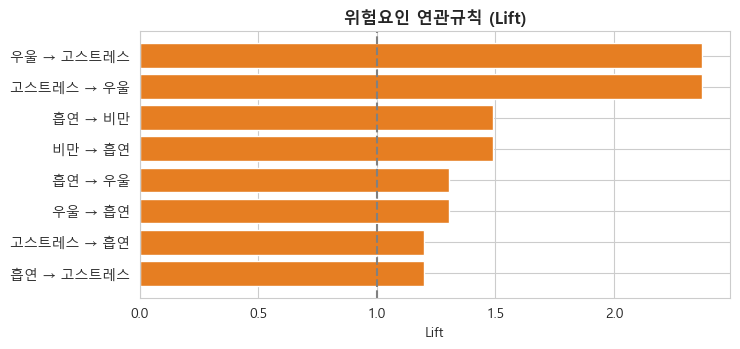

In [ ]:
# 연관분석: 위험요인(흡연·고스트레스·우울·비만) 동시발생 패턴 — support/confidence/lift
A = pd.DataFrame({'흡연': ind['smoker'], '고스트레스': ind['high_stress'],
                  '우울': ind['depress_yn'], '비만': ind['비만여부']})
items = list(A.columns); rules = []
for a in items:
    for b in items:
        if a == b: continue
        sA, sB = A[a].mean(), A[b].mean()
        sAB = ((A[a]==1) & (A[b]==1)).mean()
        if sAB > 0.01 and sA > 0 and sB > 0:
            conf = sAB/sA; lift = conf/sB
            rules.append([f'{a} → {b}', round(sAB,3), round(conf,3), round(lift,3)])
rules = pd.DataFrame(rules, columns=['규칙(A→B)','support','confidence','lift'])
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False).reset_index(drop=True)
print('연관규칙 (lift>1, 동시발생이 우연보다 강한 조합):'); print(rules.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
top = rules.head(8).iloc[::-1]
ax.barh(top['규칙(A→B)'], top['lift'], color='#e67e22')
ax.axvline(1, ls='--', color='gray'); ax.set_xlabel('Lift'); ax.set_title('위험요인 연관규칙 (Lift)', fontweight='bold')
plt.tight_layout(); plt.show()


**해석** — 우울↔고스트레스(lift≈2.4)가 가장 강하게 결합하고 **흡연→비만(lift≈1.5)**도 뚜렷하다.
→ 정신건강(스트레스·우울)·흡연·비만을 **묶어서** 다루는 통합 프로그램이 효과적.

---
# PART K. 자치구 수준 회귀 — H1/H2 검정 (n=25)
개인 모델과 별개로, 환경요인이 자치구 비만율을 설명하는지 직접 검정한다.

In [ ]:
# 자치구 수준 회귀: 비만율을 환경요인으로 설명 → H1/H2 직접 검정 (n=25)
Xd = sm.add_constant(mst[['배달친화_점포비중','총체육시설수']]); yd = mst['비만율']
mdl_d = sm.OLS(yd, Xd).fit()
print(mdl_d.summary().tables[1])
print(f'\nR² = {mdl_d.rsquared:.3f}  | 관측 수 = {int(mdl_d.nobs)}개 자치구')
print('해석: 배달친화_점포비중 계수가 양(+)·유의 → H1 지지 / 총체육시설수 계수가 음(-) → H2 방향 일치')

# 군집·정책그룹 결과를 대시보드 단계 입력으로 저장
out_dir = OUT if 'OUT' in globals() else '_processed/'
os.makedirs(out_dir, exist_ok=True)
mst.to_csv(out_dir + 'master_clustered.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ 군집·정책그룹 결과 저장: {out_dir}master_clustered.csv')


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.7480      3.453      4.850      0.000       9.586      23.910
배달친화_점포비중    103.2265     27.591      3.741      0.001      46.007     160.446
총체육시설수        -0.0021      0.002     -1.377      0.182      -0.005       0.001

R² = 0.453  | 관측 수 = 25개 자치구
해석: 배달친화_점포비중 계수가 양(+)·유의 → H1 지지 / 총체육시설수 계수가 음(-) → H2 방향 일치

✅ 군집·정책그룹 결과 저장: ./master_clustered.csv


In [ ]:
# [PBL#1 요소] 다중공선성 점검(VIF) — 자치구 회귀 독립변수
vif_dist = vif_table(mst[['배달친화_점포비중','총체육시설수']])
print('■ VIF (자치구 회귀, n=25)')
print(vif_dist.round(3).to_string(index=False))
print('판정 →', '모든 변수 VIF<5, 다중공선성 문제 없음' if (vif_dist['VIF']<5).all() else '주의')

■ VIF (자치구 회귀, n=25)
       변수  VIF
배달친화_점포비중 1.03
   총체육시설수 1.03
판정 → 모든 변수 VIF<5, 다중공선성 문제 없음


---
# PART L. 종합 정책 인사이트

### 데이터 기반 진단
1. **H1 채택** — 청년 비만율은 배달친화 외식환경과 강하게 연동(점포비중 r≈+0.64, 자치구회귀 계수 양·유의).
2. **H2 부분 지지** — 체육시설이 많을수록 비만율이 낮은 경향(r≈−0.31, 자치구회귀 음의 계수).
3. **개인 위험요인** — 고스트레스·흡연·수면부족이 비만 위험을 높이고(로지스틱 OR>1),
   흡연↔비만·우울↔고스트레스가 동시발생(연관분석 lift>1).

### 정책 제안 (타겟 · 수단 · 기대효과)
| 타겟(군집) | 수단 | 기대효과 |
|---|---|---|
| **시설 취약 그룹** | 생활체육시설·청년 운동바우처 확충 | 체육시설↑ → 비만율↓ (H2) |
| **외식환경 취약 그룹** | 배달밀집 상권 건강식 인센티브·영양표시 강화 | 배달친화 비중↓ → 비만율↓ (H1) |
| **전체 고위험 개인** | 흡연·스트레스·수면 통합 청년 생활습관 클리닉 | 동시발생 위험요인 차단 (연관·로지스틱) |

> 추상적 '노력' 제안이 아니라, **군집으로 식별된 구체적 자치구 그룹**에 **데이터로 검증된 수단**을
> 매칭했다. 다음 단계로 `_processed/master_clustered.csv`를 입력 삼아 **정책 결정 대시보드**를 구축한다.

### 분석의 한계 (해석 시 유의)
- **연관 ≠ 인과**: 회귀·상관·연관분석 결과는 변수 간 *연관성*이며, 정책 수단의 인과효과는 향후
  준실험(전후 비교·이중차분 등)으로 추가 검증이 필요하다.
- **횡단면 통합**: 측정시점이 다른 데이터를 자치구별 다년 평균으로 통일했으므로 시점 변화는 일부 평활화된다.
- **표본·자기보고**: 지역사회건강조사는 자기보고 설문이며, 자치구 n=25로 자치구 모델의 통계력은 제한적이다.

---
*하이파이브 팀 | 데이터사이언스개론 PBL #2 | 26-1*